# IzzyViz Quick Start: Qwen2.5-1.5B Attention Workflow

This tutorial follows the system workflow:

**Attention Tensors -> Overview -> Select -> Inspect -> Explore**

Example setup:

- Model: `Qwen/Qwen2.5-1.5B`
- No RAG: the input is the raw context plus question.
- `x = context + question`
- `y = answer`
- Main analysis matrix: answer tokens attending to context/question tokens.

All figures are saved to `izzyviz_qwen25_outputs/` and displayed inline once.

## 0. Install IzzyViz

For Colab, the safest installation strategy is to keep Colab's preinstalled PyTorch/NumPy binary stack unchanged and install only the packages this tutorial needs. Reinstalling `torch`, `torchvision`, or `numpy` inside Colab often creates binary-version conflicts.

If a previous run already changed those packages, use `Runtime -> Disconnect and delete runtime`, then rerun this notebook from the first cell.

If the Colab kernel still restarts during model loading or attention extraction, reduce the input length first. Full attention tensors scale quadratically with sequence length, so long contexts can trigger an out-of-memory restart without a Python traceback.

If you are developing locally, replace the GitHub install line with:

```python
%pip install -e /path/to/IzzyViz
```

In [1]:
# Colab-friendly install:
# - Do not reinstall torch, torchvision, numpy, scipy, or pandas.
# - Install IzzyViz without dependency resolution so pip does not disturb
#   Colab's preinstalled binary stack.
# - Install only the notebook-facing packages that may be missing.
%pip install -q --upgrade --no-deps git+https://github.com/zoeyada/IzzyViz.git
%pip install -q --upgrade "transformers==4.46.3" "accelerate>=0.26.0" gdown pybind11

# Check the versions we will use. If torch/torchvision were modified by a
# previous failed run, restart with Runtime -> Disconnect and delete runtime.
import importlib.util
import numpy as np
import torch

print('NumPy:', np.__version__)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('torchvision installed:', importlib.util.find_spec('torchvision') is not None)
print('Dependencies are ready.')

NumPy: 1.26.4
Torch: 2.6.0+cu124
CUDA available: True
torchvision installed: False
Dependencies are ready.


## 1. Setup

This tutorial uses library functions from `izzyviz`:

- `visualize_attention_overview_fast`: pure Layer x Head overview without selection or clustering.
- `select_attention_heads_by_metric`: metric-based head ranking.
- `cluster_attention_heads`: clustering-based representative head selection.
- `visualize_attention_matrix`: detailed single-head IzzyViz heatmap with optional virtual tokens.
- variant functions for comparison, stability, and evolution heatmaps.

In [2]:
import gc
import json
import os
import time
from pathlib import Path

# This tutorial is torch-only and text-only. In Colab, letting transformers
# auto-detect optional TensorFlow/JAX/vision backends can add large imports or
# trigger binary mismatches before the Qwen text model is loaded.
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('TRANSFORMERS_NO_TF', '1')
os.environ.setdefault('USE_FLAX', '0')
os.environ.setdefault('TRANSFORMERS_NO_FLAX', '1')
os.environ.setdefault('TRANSFORMERS_NO_TORCHVISION', '1')
os.environ.setdefault('PYDEVD_DISABLE_FILE_VALIDATION', '1')
try:
    import transformers.utils.import_utils as _tf_import_utils
    _tf_import_utils._tf_available = False
    _tf_import_utils._flax_available = False
    _tf_import_utils._torchvision_available = False
except Exception:
    pass

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Image
from transformers import AutoModelForCausalLM, AutoTokenizer

from izzyviz import (
    visualize_attention_overview_fast,
    select_attention_heads_by_metric,
    select_distinctive_attention_heads_by_features,
    extract_attention_head_features,
    cluster_attention_heads,
    visualize_attention_matrix,
    compare_two_attentions_with_circles,
    check_stability_heatmap_with_gradient_color,
    visualize_attention_evolution_sparklines,
)

# Optional mirror if needed:
# os.environ.setdefault('HF_ENDPOINT', 'https://hf-mirror.com')

OUTPUT_DIR = Path('izzyviz_qwen25_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Figure switches decide which visual outputs are produced by each workflow step.
# SAVE_DATA_OUTPUTS controls JSON/data summaries such as run_summary.json and
# metric_selection_summary.json. Set it to False for a cleaner demo folder.
SAVE_DATA_OUTPUTS = True


def show_image(path, width=1000):
    path = Path(path)
    print(path)
    display(Image(filename=str(path), width=width))

print('Output directory:', OUTPUT_DIR.resolve())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Output directory: /home/cuizhouying/IzzyViz/izzyviz_qwen25_outputs
Torch: 2.6.0+cu124
CUDA available: True


## 2. Attention Tensors

This section obtains the raw attention tensors used by the rest of the workflow.

### 2.1 Load Model

Important parameters:

- `MODEL_NAME`: Hugging Face model id. You can replace it with another causal LM.
- `attn_implementation='eager'`: important for attention analysis. Some optimized attention kernels do not return full attention tensors.
- `torch_dtype`: `bfloat16` / `float16` on GPU, `float32` on CPU.
- `model.eval()`: disables training behavior.

In [3]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported():
    MODEL_DTYPE = torch.bfloat16
elif DEVICE.type == 'cuda':
    MODEL_DTYPE = torch.float16
else:
    MODEL_DTYPE = torch.float32

print('Loading tokenizer:', MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

print('Loading model:', MODEL_NAME)
t0 = time.time()
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation='eager',
    trust_remote_code=True,
)
model.to(DEVICE)
model.eval()
print('Loaded in', round(time.time() - t0, 1), 's')
print('Device:', DEVICE)
print('Model dtype:', next(model.parameters()).dtype)

Loading tokenizer: Qwen/Qwen2.5-1.5B
Loading model: Qwen/Qwen2.5-1.5B
Loaded in 2.1 s
Device: cuda
Model dtype: torch.bfloat16


### 2.2 Build the QA Prompt

We include the answer in the prompt so that answer-token rows can be inspected.

For decoder-only LMs, the attention row for an answer token tells us which earlier tokens the model used when representing that answer token.

Spans used throughout:

- `key_slice=(0, x_end)`: columns, `x = context + question`.
- `query_slice=(answer_start, answer_end)`: rows, `y = answer`.

In [4]:
BASE_CONTEXT = (
    "The Rev. John J. Cavanaugh, C.S.C. served as president from 1946 to 1952. "
    "Cavanaugh's legacy at Notre Dame in the post-war years was devoted to raising academic standards "
    "and reshaping the university administration to suit it to an enlarged educational mission and an expanded "
    "student body and stressing advanced studies and research at a time when Notre Dame quadrupled in student census, "
    "undergraduate enrollment increased by more than half, and graduate student enrollment grew fivefold. "
    "Cavanaugh also established the Lobund Institute for Animal Studies and Notre Dame's Medieval Institute. "
    "Cavanaugh also presided over the construction of the Nieuwland Science Hall, Fisher Hall, and the Morris Inn, "
    "as well as the Hall of Liberal Arts (now O'Shaughnessy Hall), made possible by a donation from I.A. O'Shaughnessy, "
    "at the time the largest ever made to an American Catholic university. "
    "Cavanaugh also established a system of advisory councils at the university, which continue today and are vital "
    "to the university's governance and development."
)
QUESTION = 'Which institute involving animal life did Cavanaugh create at Notre Dame?'
ANSWER = 'Lobund Institute for Animal Studies'

context_text = f'Context: {BASE_CONTEXT}\n'
question_text = f'Question: {QUESTION}\n'
answer_prefix = 'Answer:'
answer_text = f' {ANSWER}'

x_text = context_text + question_text
prompt = x_text + answer_prefix + answer_text

inputs = tokenizer(prompt, return_tensors='pt', add_special_tokens=False).to(DEVICE)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

x_end = len(tokenizer(x_text, add_special_tokens=False)['input_ids'])
answer_start = len(tokenizer(x_text + answer_prefix, add_special_tokens=False)['input_ids'])
answer_end = len(tokens)

print('Sequence length:', len(tokens))
print('x span = context + question:', (0, x_end))
print('y span = answer:', (answer_start, answer_end))
print('Answer tokens:', tokens[answer_start:answer_end])

Sequence length: 243
x span = context + question: (0, 235)
y span = answer: (237, 243)
Answer tokens: ['ĠLob', 'und', 'ĠInstitute', 'Ġfor', 'ĠAnimal', 'ĠStudies']


### 2.3 Run Forward Pass

Important parameters:

- `output_attentions=True`: returns all attention tensors.
- `return_dict=True`: keeps Hugging Face outputs named and easy to access.
- `use_cache=False`: avoids generation-cache behavior; this is simpler for full-sequence analysis.

The resulting `attentions` object is a tuple with one tensor per layer. Each tensor has shape:

`[batch, heads, query_tokens, key_tokens]`

In [5]:
print('Running model forward pass...')
t0 = time.time()
with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True,
        return_dict=True,
        use_cache=False,
    )
print('Forward done in', round(time.time() - t0, 1), 's')

attentions = outputs.attentions
num_layers = len(attentions)
num_heads = attentions[0].shape[1]

print('Layers:', num_layers)
print('Heads per layer:', num_heads)
print('Layer 0 attention shape:', tuple(attentions[0].shape))

# Convenience NumPy region for single-head inspection later.
attention_region = np.stack([
    layer_attn[0, :, answer_start:answer_end, 0:x_end].detach().float().cpu().numpy()
    for layer_attn in attentions
])
x_labels = tokens[:x_end]
y_labels = tokens[answer_start:answer_end]
print('answer -> context/question region:', attention_region.shape)

Running model forward pass...
Forward done in 0.7 s
Layers: 28
Heads per layer: 12
Layer 0 attention shape: (1, 12, 243, 243)
answer -> context/question region: (28, 12, 6, 235)


## 3. Overview

The first visualization is a pure overview of the full Layer x Head space. It does **not** use metric selection or clustering.

We show two overview variants:

1. **Full-token overview**: keeps the answer rows and compresses only very long columns for compact display.
2. **Virtual-token overview**: merges unimportant contiguous token runs, preserving rows/columns that contain top attention cells.

Important parameters for `visualize_attention_overview_fast`:

- `attentions`: Hugging Face attention tuple or compatible attention array.
- `query_slice`: rows to visualize. Here, answer tokens.
- `key_slice`: columns to visualize. Here, context + question tokens.
- `shared_color_scale=True`: one global color scale for all heads; colors are comparable across the grid.
- `shared_cbar=True`: show the right-side colorbar.
- `max_display_cols`: only used by the full-token overview to keep long contexts compact.
- `merge_virtual_tokens=True`: creates the virtual-token overview.
- `overview_top_n`: top cells used to decide which rows/columns are preserved in the virtual-token overview.
- `show_merge_token_labels=True`: shows token indices in the virtual-token overview; important indices are highlighted with a pink background.

izzyviz_qwen25_outputs/01_pure_overview_answer_to_context_question.png
izzyviz_qwen25_outputs/01_pure_overview_answer_to_context_question_merge_tokens.png


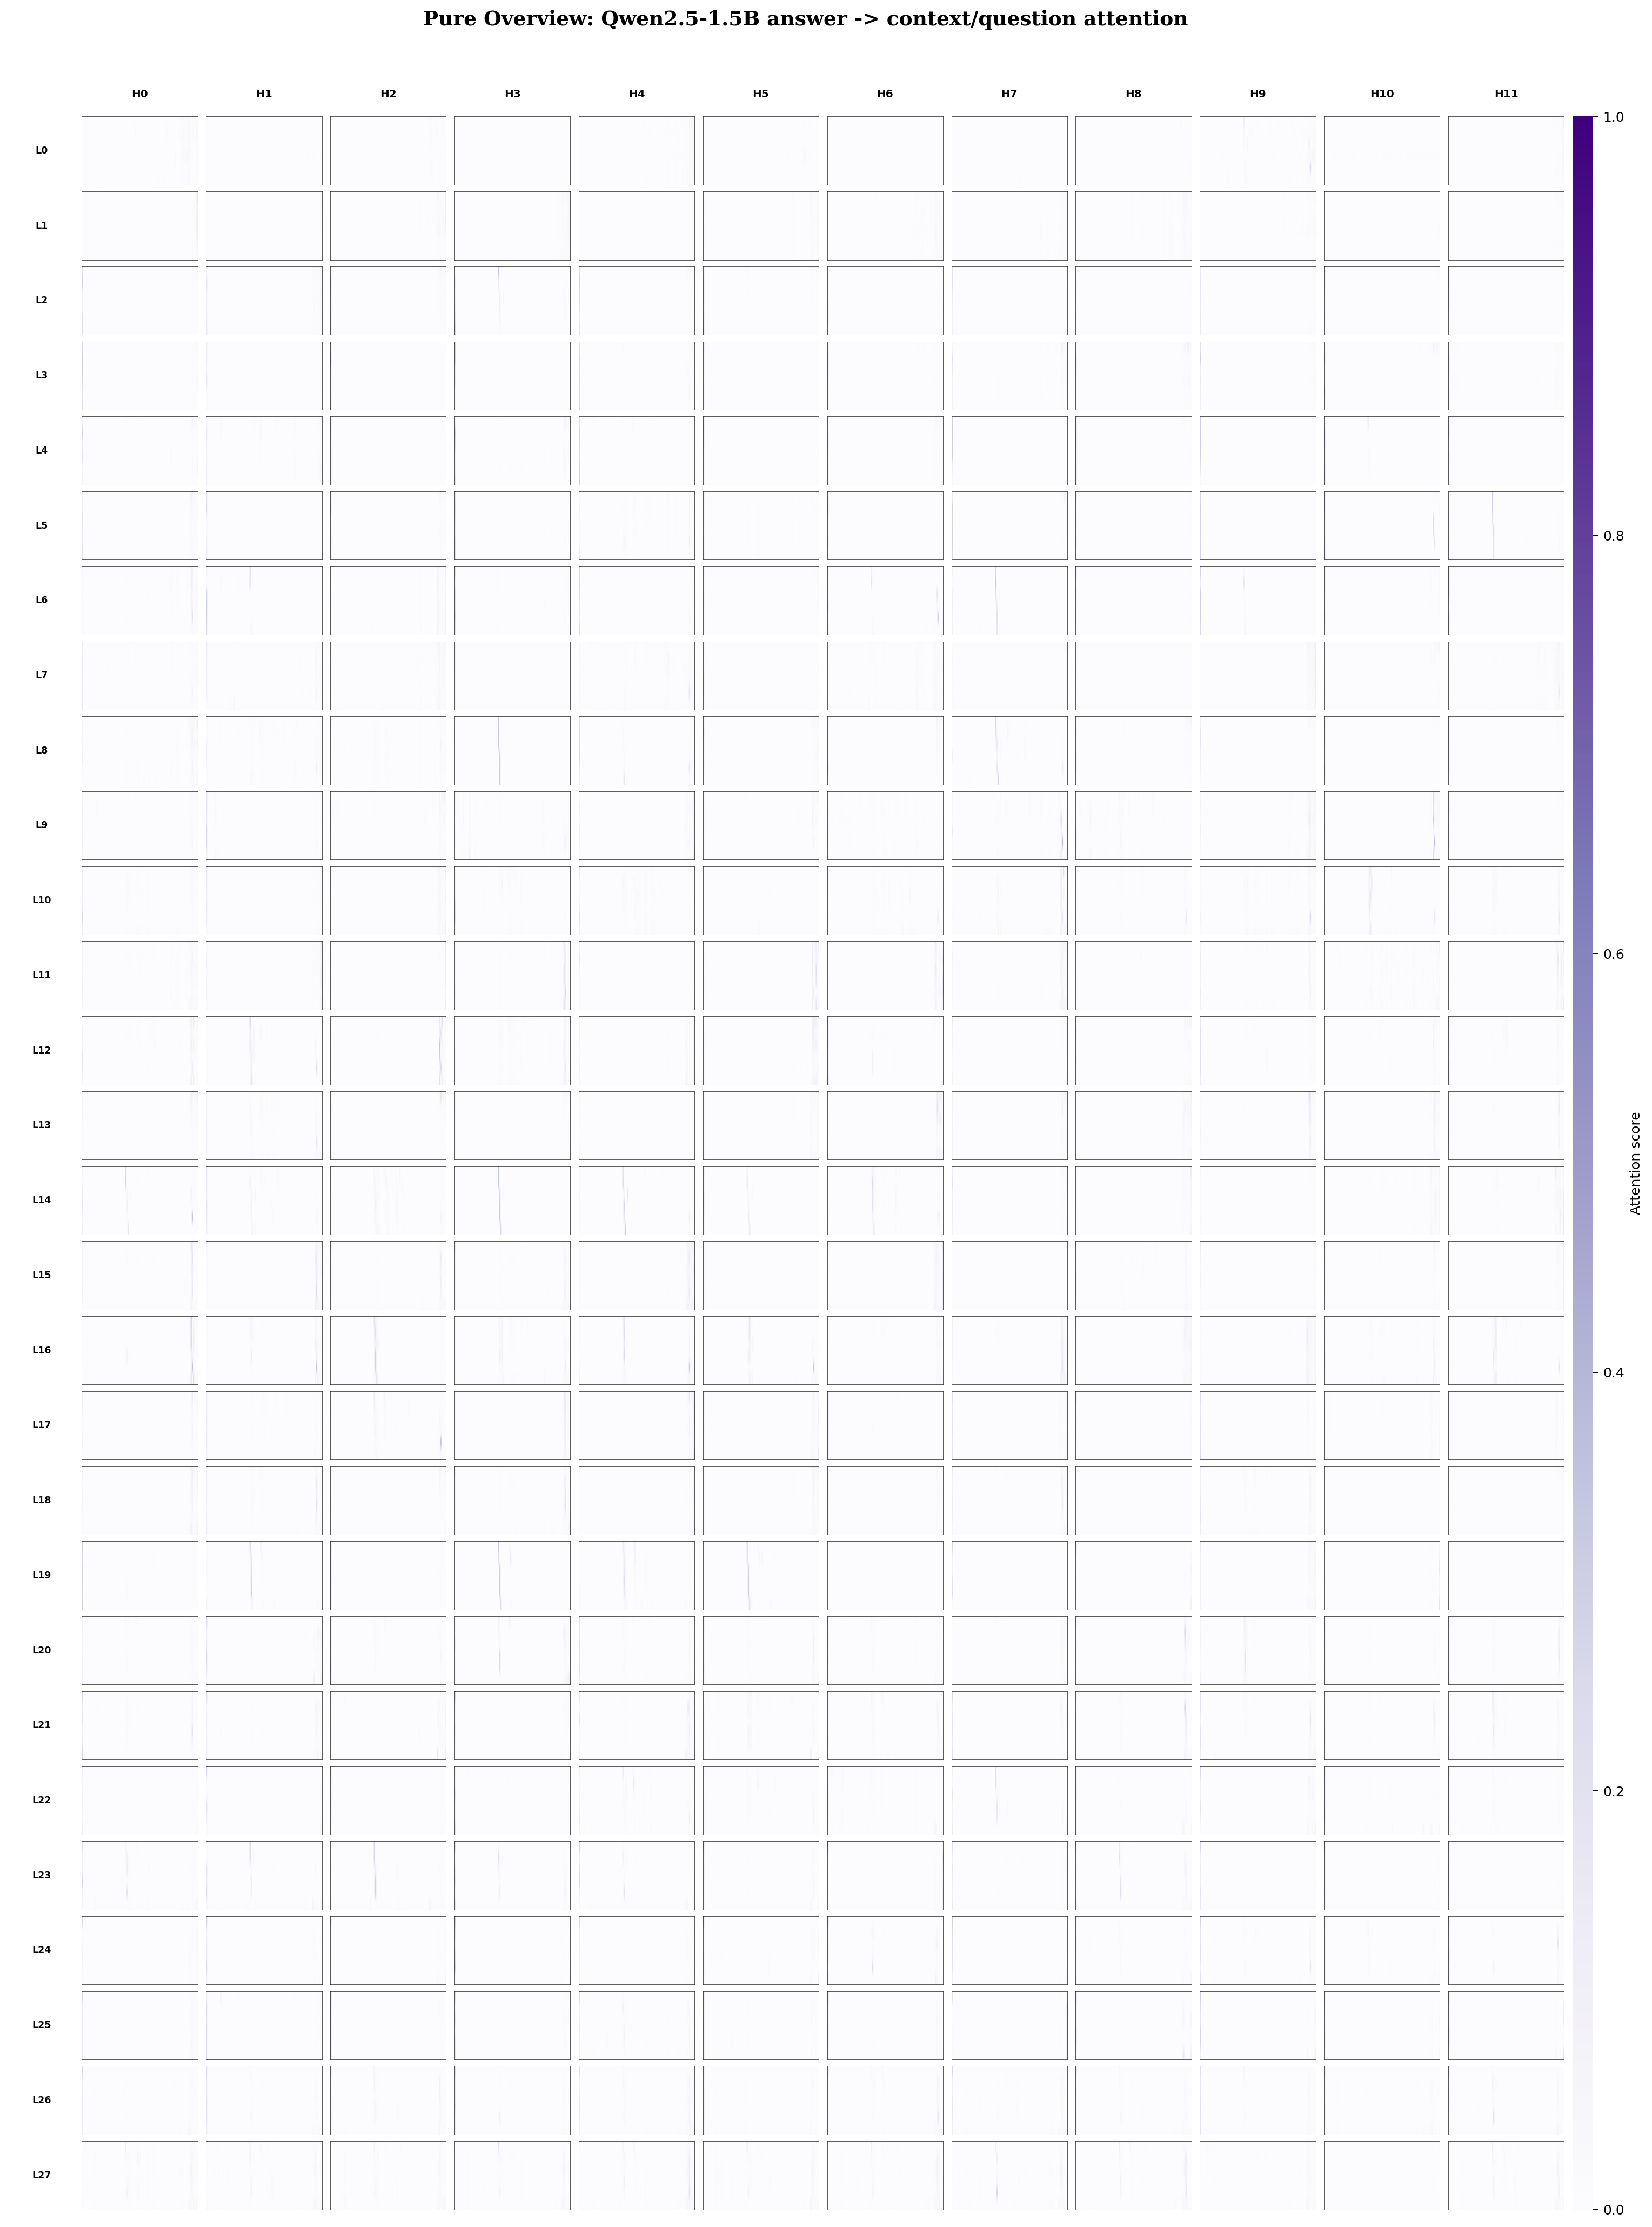

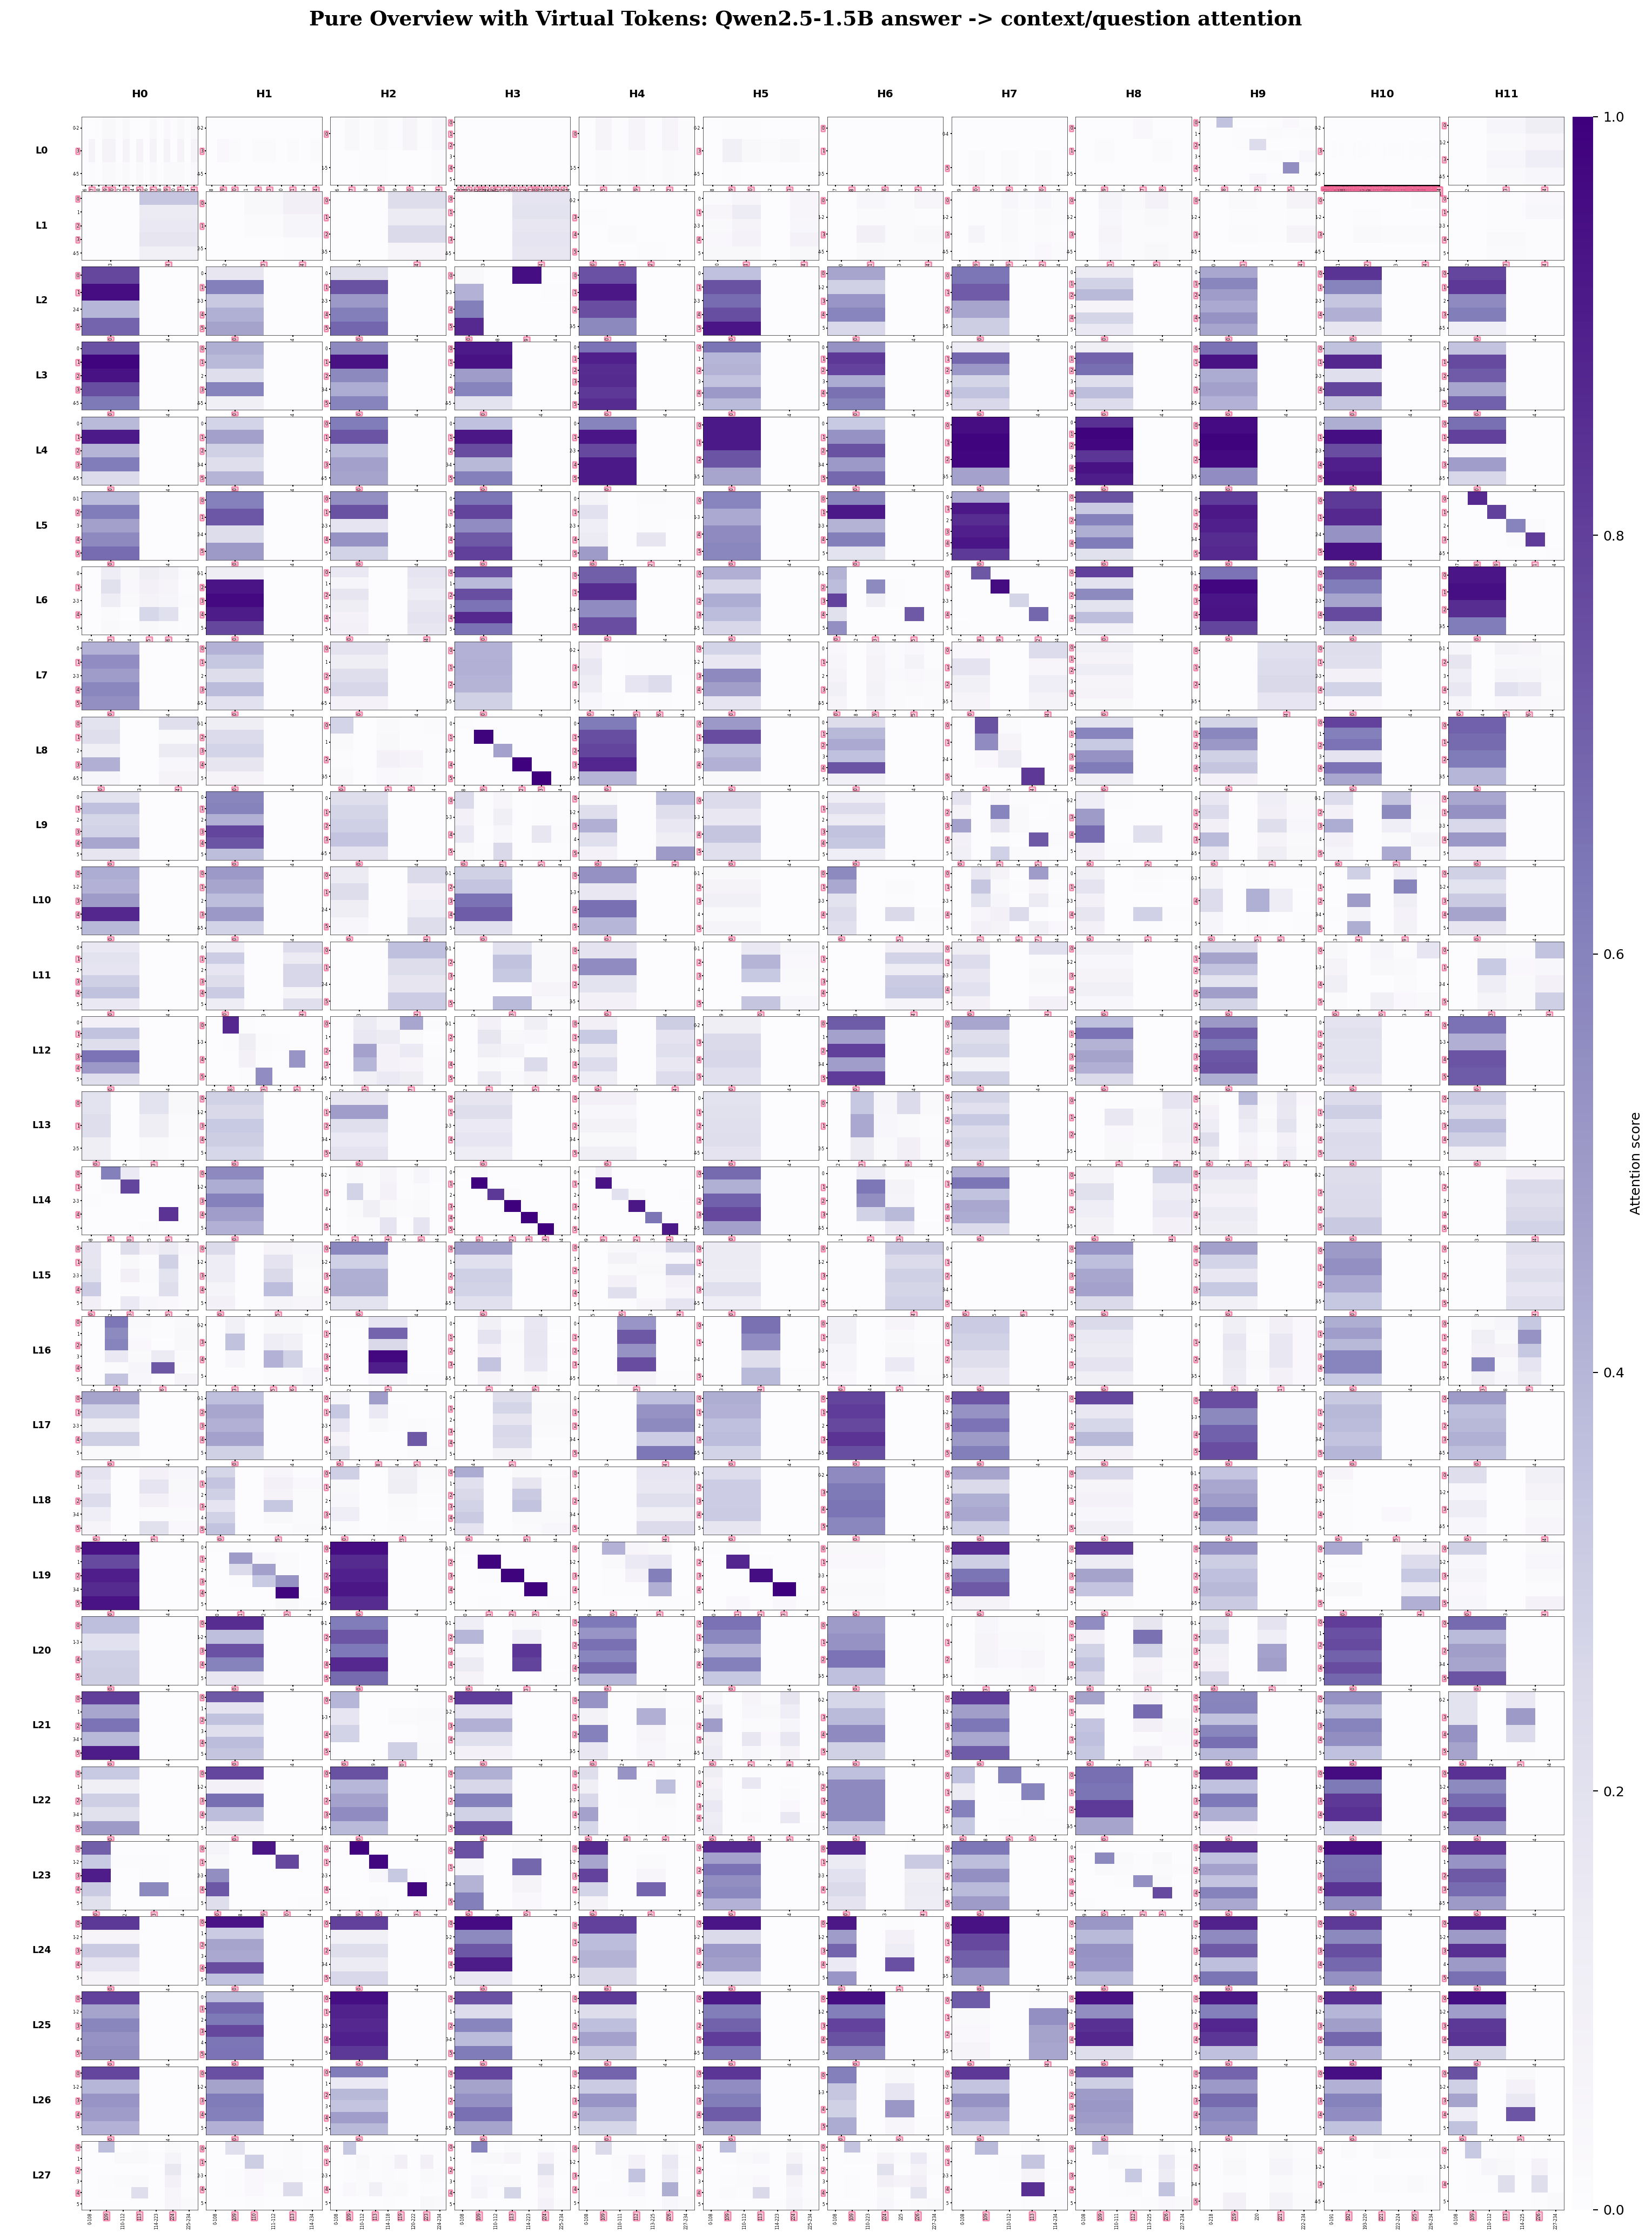

In [6]:
overview_path = OUTPUT_DIR / '01_pure_overview_answer_to_context_question.png'
fig, axes = visualize_attention_overview_fast(
    attentions,
    query_slice=(answer_start, answer_end),
    key_slice=(0, x_end),
    title='Pure Overview: Qwen2.5-1.5B answer -> context/question attention',
    save_path=overview_path,
    shared_color_scale=True,
    shared_cbar=True,
    shared_cbar_label='Attention score',
    max_display_cols=96,
    close_after_save=True,
)
show_image(overview_path)

overview_merge_path = OUTPUT_DIR / '01_pure_overview_answer_to_context_question_merge_tokens.png'
fig, axes = visualize_attention_overview_fast(
    attentions,
    query_slice=(answer_start, answer_end),
    key_slice=(0, x_end),
    title='Pure Overview with Virtual Tokens: Qwen2.5-1.5B answer -> context/question attention',
    save_path=overview_merge_path,
    shared_color_scale=True,
    shared_cbar=True,
    shared_cbar_label='Attention score',
    merge_virtual_tokens=True,
    overview_top_n=3,
    show_merge_token_labels=True,
    merge_token_label_mode='index',
    merge_token_important_label_mode='index',
    merge_token_label_fontsize=3,
    x_labels=x_labels,
    y_labels=y_labels,
    close_after_save=True,
)
show_image(overview_merge_path)

## 4. Select

Selection reduces redundant inspection. This tutorial shows two selection strategies:

1. Metric-based ranking.
2. Clustering-based representative head selection.

### 4.1 Metric-Based Head Ranking

`select_attention_heads_by_metric` ranks every layer/head by one filtering metric.

Important parameters:

- `query_slice`: rows in the score/display region. Here, answer tokens.
- `key_slice`: columns in the score/display region. Here, context + question tokens.
- `metric_name`: filtering metric to rank heads.
- `metric_params`: metric-specific parameters.
- `ignore_first_n=1`: scoring ignores the first key token only; display still includes it. This helps reduce sink-token effects.
- `top_k`: number of ranked heads to label.
- `overview_renderer='fast'`: lightweight overview with rank badges.
- `plot_overview_no_merge=True`: full-token overview.
- `plot_overview_merge=True`: virtual-token overview. In the merge view below, labels are token indices only; important indices get a pink background.
- `detail_merge_virtual_tokens=True`: top detailed maps use virtual tokens for long contexts.
- `detail_file_format`: choose `png` for notebook display or `pdf` for publication export.

Metric choices:

- `entropy`: concentrated attention.
- `variance`: high-contrast attention.
- `threshold_mass`: mass above a threshold.
- `top_percent_mass`: mass in the strongest cells.
- `low_range`: local dependency.
- `long_range`: long-distance dependency.

In [7]:
METRIC_NAME = 'long_range'
METRIC_PARAMS = {'min_distance': 20}

selection_dir = OUTPUT_DIR / f'02_select_{METRIC_NAME}'
selection_result = select_attention_heads_by_metric(
    attentions,
    query_slice=(answer_start, answer_end),
    key_slice=(0, x_end),
    tokens=tokens,
    metric_name=METRIC_NAME,
    metric_params=METRIC_PARAMS,
    ignore_first_n=1,
    top_k=8,
    output_dir=selection_dir,
    run_name=f'qwen25_15b_{METRIC_NAME}_answer_to_x',
    plot_overview=True,
    plot_overview_no_merge=True,
    plot_overview_merge=True,
    plot_importance_heatmap=True,
    plot_top_attention_maps=True,
    top_attention_count=3,
    overview_renderer='fast',
    overview_top_n=3,
    overview_kwargs={
        'figsize': (30, 50),
        'shared_cbar': True,
        'shared_cbar_label': 'Attention score',
        'highlight_top_cells': True,
        'highlight_ranked_only_no_merge': True,
        'highlight_ranked_only_merge': False,
        'show_merge_token_labels': True,
        'merge_token_label_mode': 'index',
        'merge_token_important_label_mode': 'index',
        'merge_token_label_fontsize': 3,
        'wspace': 0.24,
        'hspace': 0.26,
    },
    detail_top_n=20,
    detail_merge_virtual_tokens=True,
    detail_file_format='png',
    detail_kwargs={
        'xlabel': 'x: Context + Question',
        'ylabel': 'y: Answer',
        'length_threshold': 64,
        'if_interval': False,
        'if_top_cells': True,
        'show_scores_in_enlarged_cells': False,
        'lean_more': True,
    },
    close_after_save=True,
    save_summary=SAVE_DATA_OUTPUTS,
)

for record in selection_result['top_records']:
    print(f"rank {record['rank']:02d}: L{record['layer']:02d} H{record['head']:02d}, score={record['score']:.6f}")

rank 01: L08 H03, score=0.999081
rank 02: L14 H03, score=0.998935
rank 03: L19 H03, score=0.998504
rank 04: L06 H07, score=0.998265
rank 05: L19 H05, score=0.998124
rank 06: L16 H02, score=0.996946
rank 07: L06 H09, score=0.992057
rank 08: L14 H05, score=0.989226


izzyviz_qwen25_outputs/02_select_long_range/overview_no_merge.png
izzyviz_qwen25_outputs/02_select_long_range/overview_merge_tokens.png
izzyviz_qwen25_outputs/02_select_long_range/importance_heatmap.png
izzyviz_qwen25_outputs/02_select_long_range/rank_01_L8_H3_attention.png
izzyviz_qwen25_outputs/02_select_long_range/rank_02_L14_H3_attention.png
izzyviz_qwen25_outputs/02_select_long_range/rank_03_L19_H3_attention.png


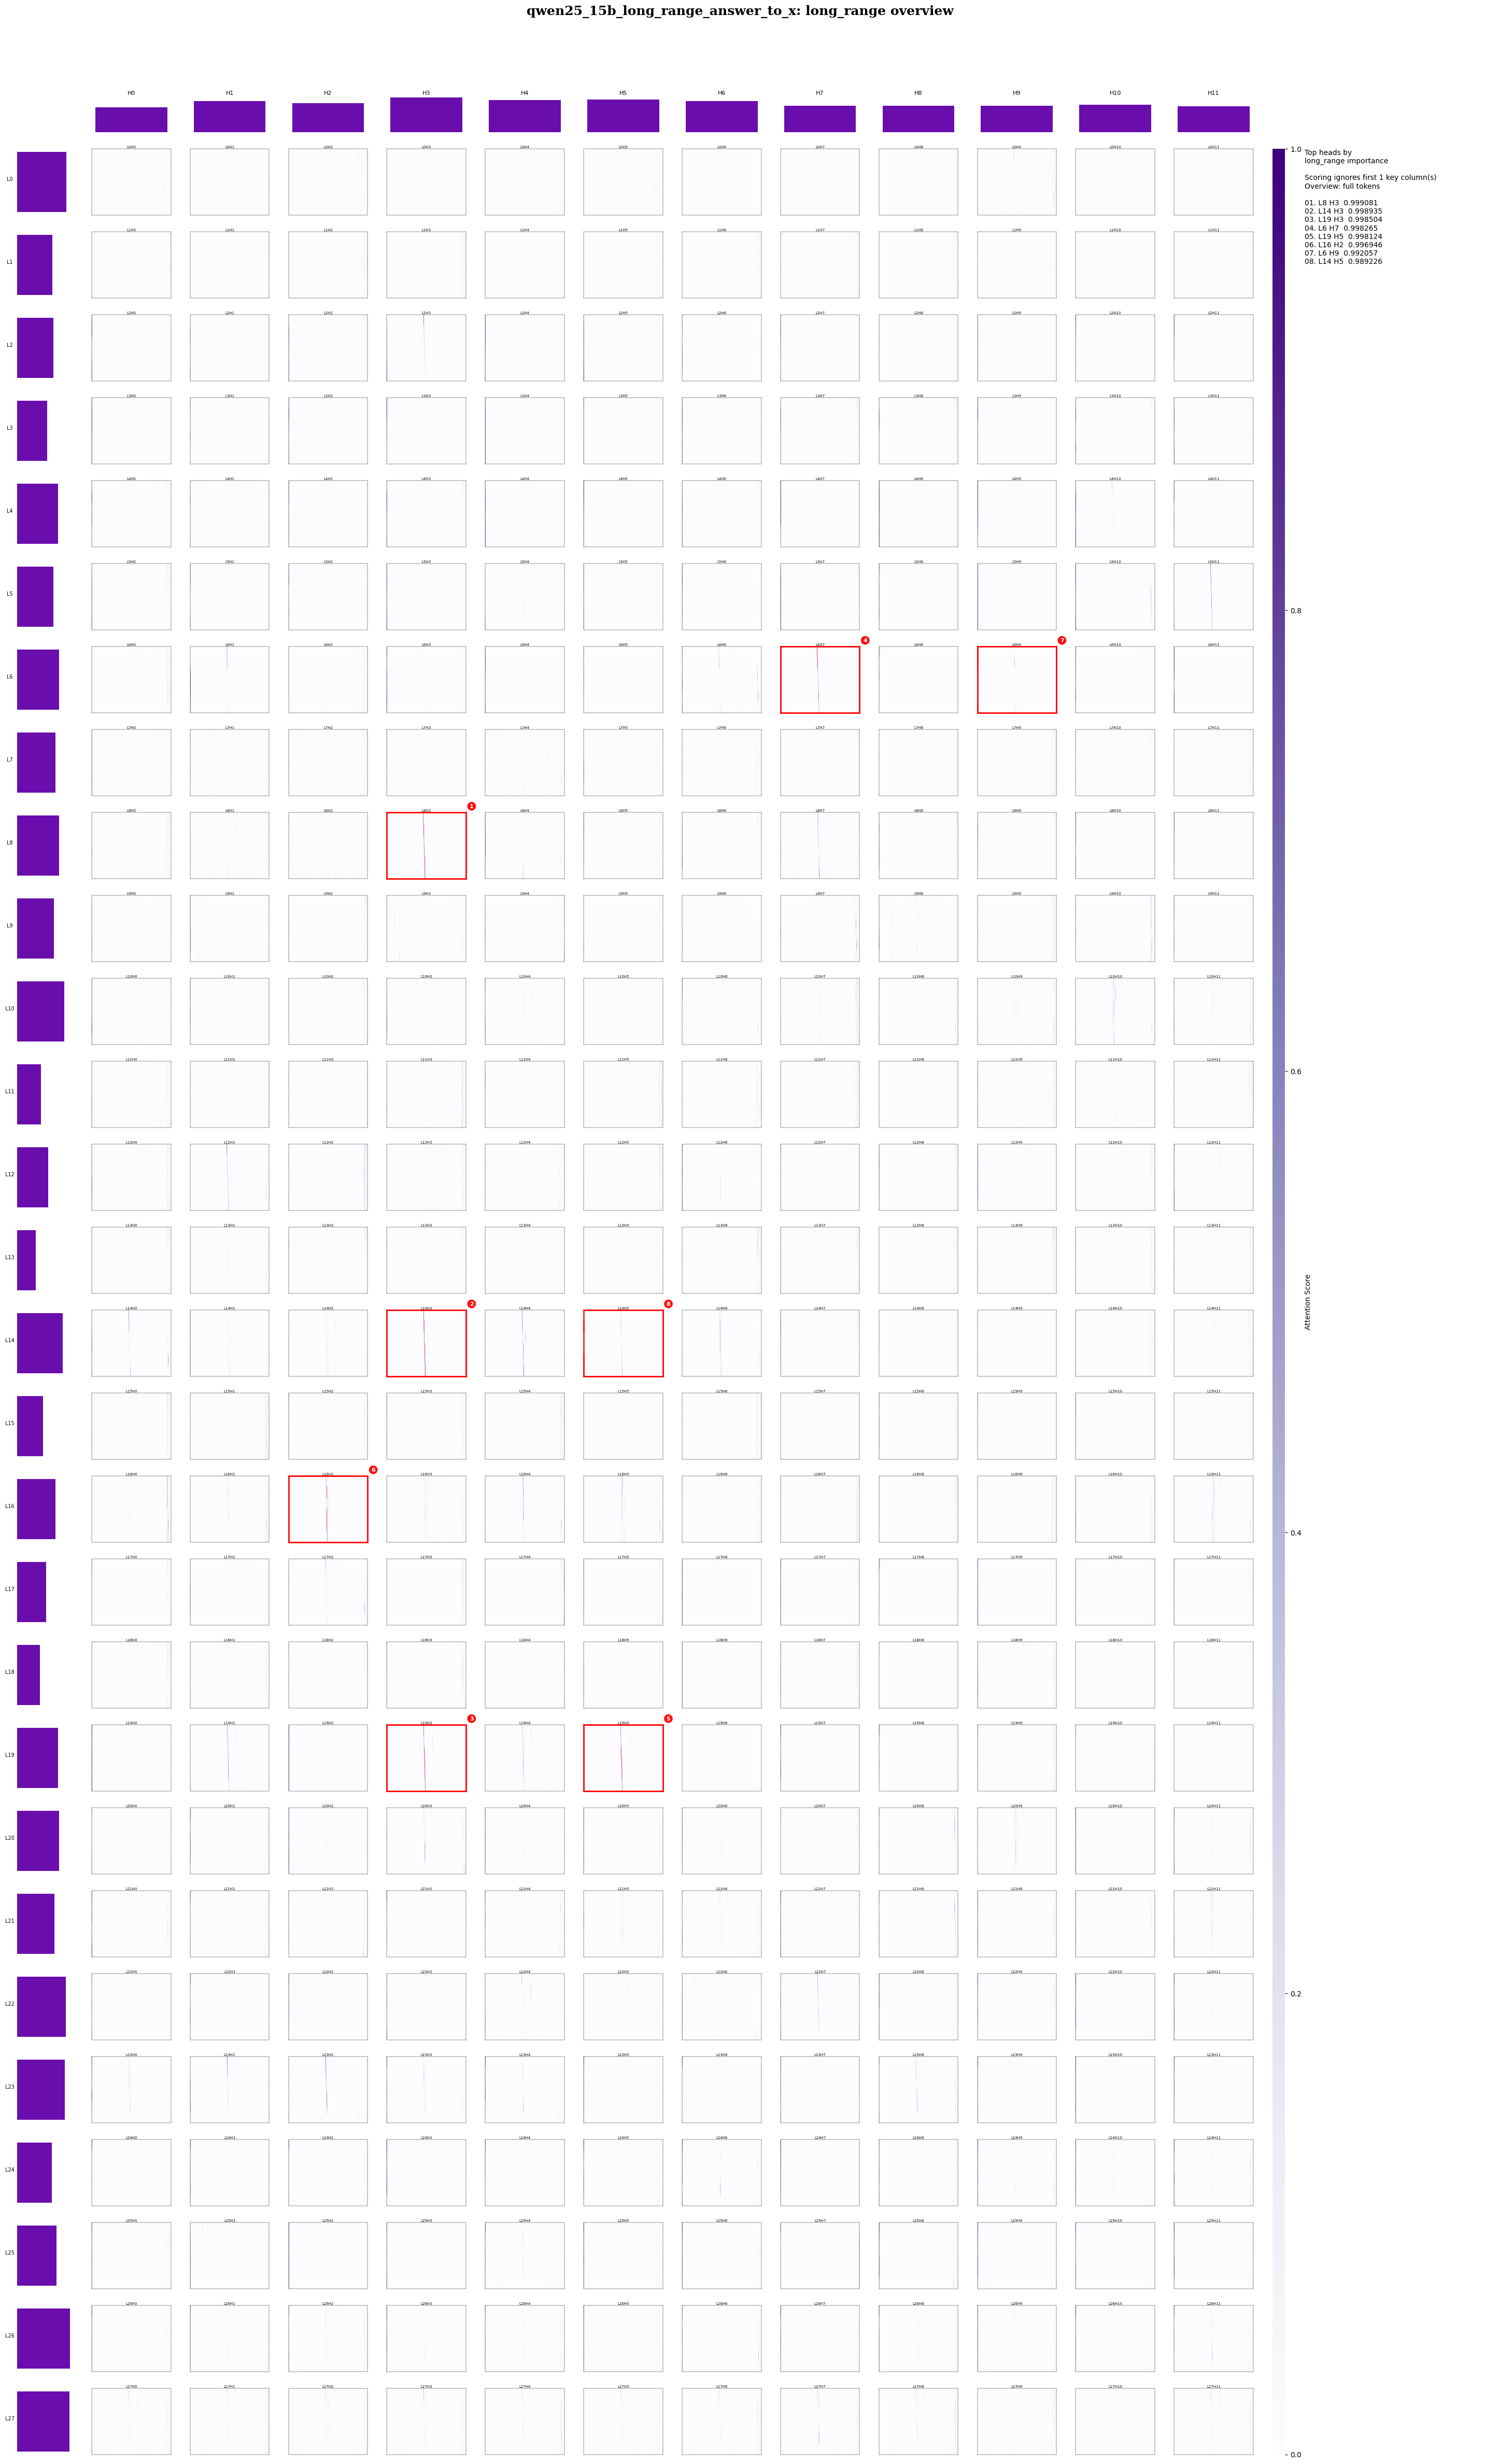

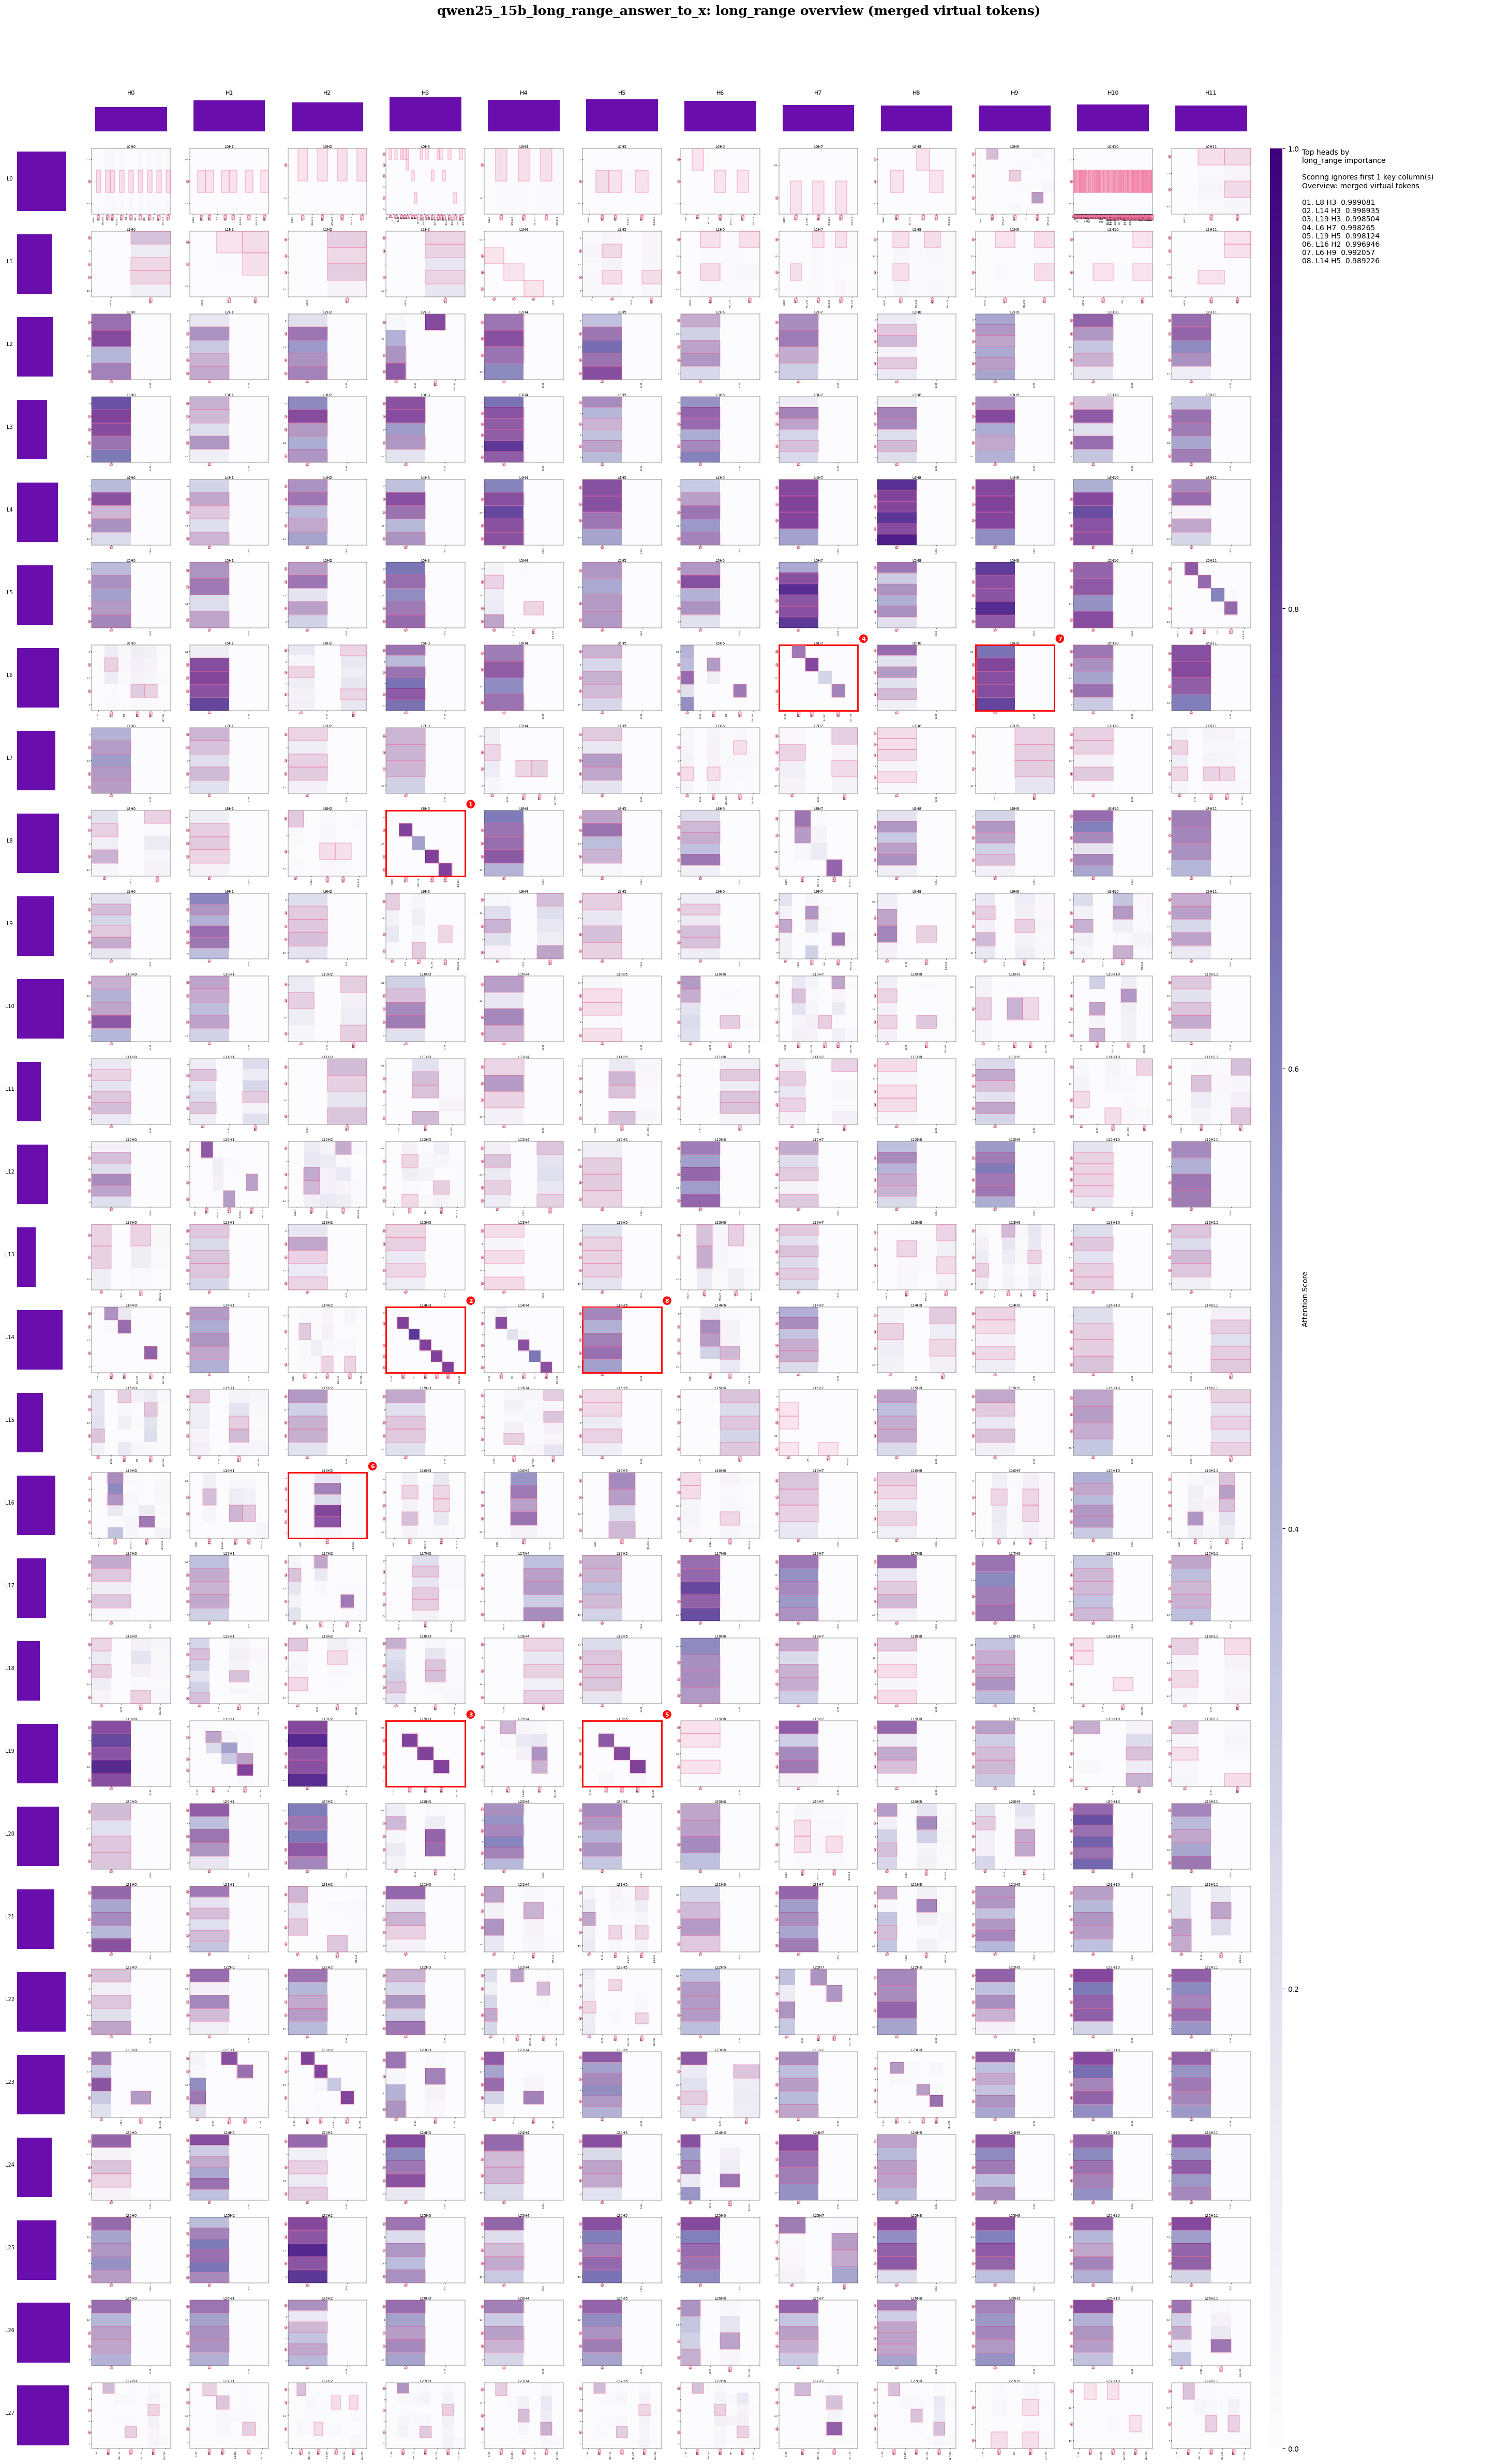

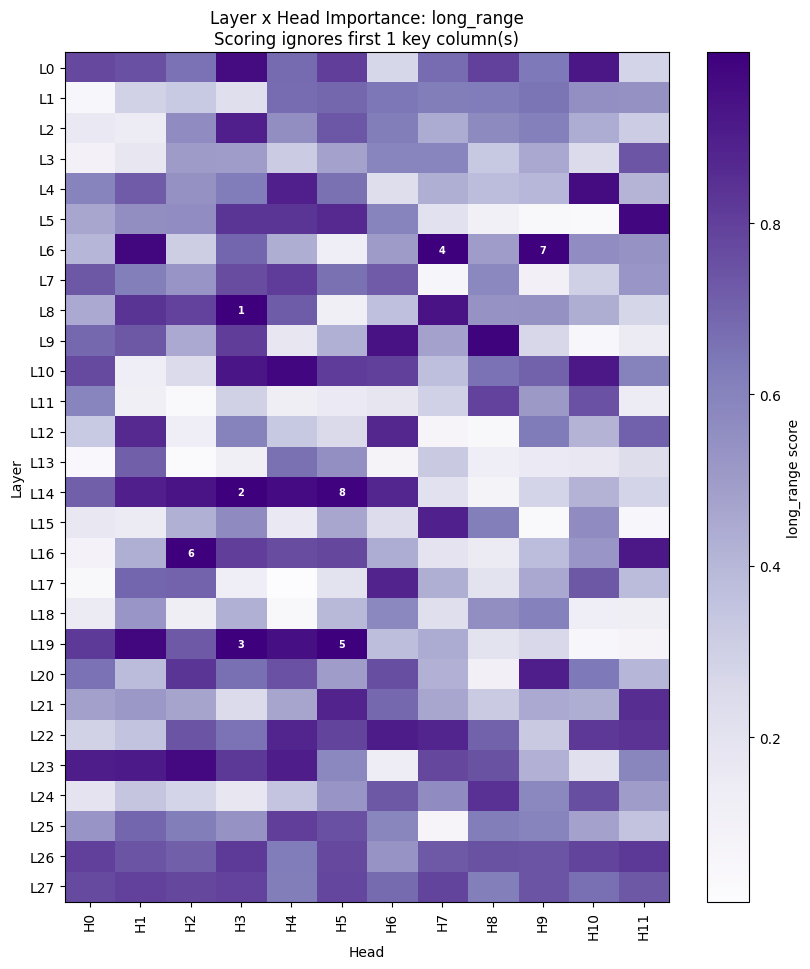

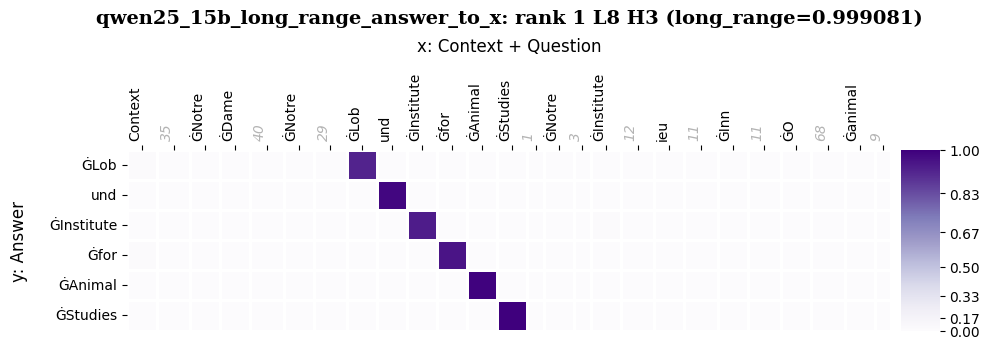

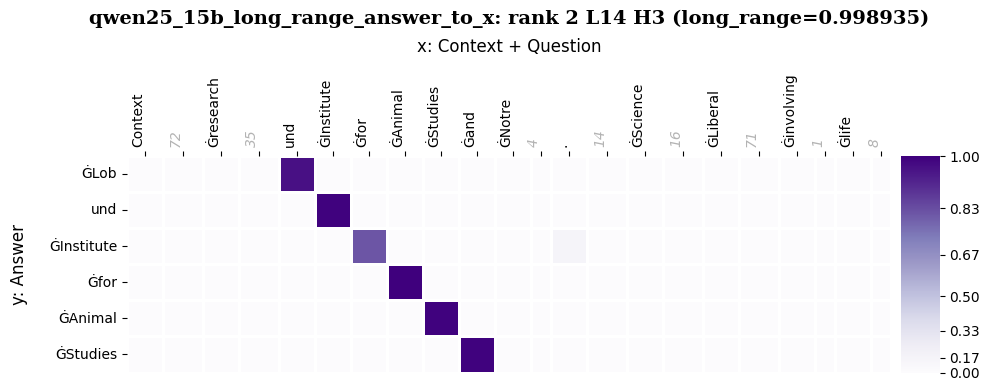

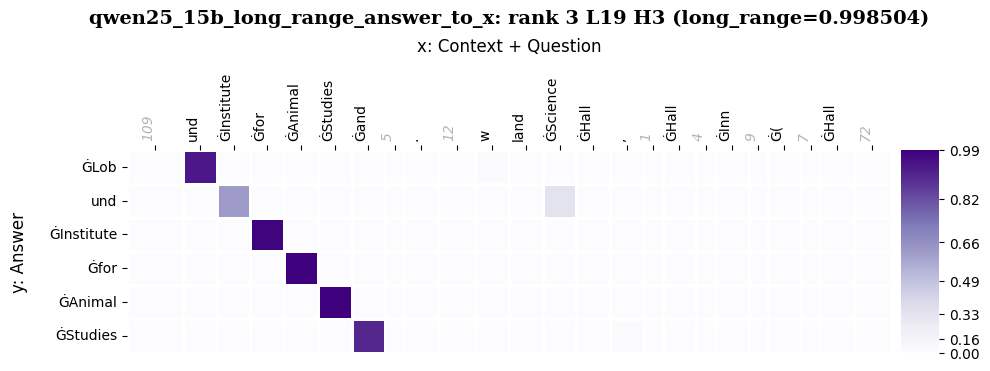

In [8]:
show_image(selection_result['output_paths']['overview_no_merge'])
show_image(selection_result['output_paths']['overview_merge'])
show_image(selection_result['output_paths']['importance_heatmap'], width=900)

# Display the selected top heads as detailed IzzyViz heatmaps.
# These are generated by select_attention_heads_by_metric because
# plot_top_attention_maps=True and detail_file_format='png'.
for detail_path in selection_result['output_paths'].get('top_attention_maps', [])[:3]:
    show_image(detail_path, width=1000)

### 4.2 Clustering-Based Representative Heads

`cluster_attention_heads` uses multiple metrics as features, clusters heads, and selects representative heads.

Important parameters:

- `metrics`: feature list for clustering.
- `metric_params`: per-metric parameter dictionary.
- `n_clusters`: number of behavior groups.
- `representative_per_cluster`: number of representative heads per cluster.
- `ignore_first_n`: same sink-token scoring control as metric ranking.
- `plot_pca=True`: shows a 2D PCA view of the clustered feature space.
- `plot_detail_heatmaps=True`: saves detailed heatmaps for representative heads.
- `plot_overview_merge=True`: virtual-token overview; labels are token indices, important indices are highlighted in pink.

In [10]:
cluster_dir = OUTPUT_DIR / '03_cluster_representative_heads'
cluster_result = cluster_attention_heads(
    attentions,
    query_slice=(answer_start, answer_end),
    key_slice=(0, x_end),
    tokens=tokens,
    metrics=[
        'concentration',
        'entropy',
        'variance',
        'threshold_mass',
        'top_percent_mass',
        'low_range',
        'long_range',
    ],
    metric_params={
        'threshold_mass': {'threshold': 0.05},
        'top_percent_mass': {'top_percent': 0.05},
        'low_range': {'max_distance': 5},
        'long_range': {'min_distance': 20},
    },
    n_clusters=5,
    representative_per_cluster=1,
    ignore_first_n=1,
    max_detail_plots=5,
    output_dir=cluster_dir,
    run_name='qwen25_15b_answer_to_x_cluster',
    overview_renderer='fast',
    plot_overview=True,
    plot_overview_no_merge=True,
    plot_overview_merge=True,
    plot_pca=True,
    plot_detail_heatmaps=True,
    overview_top_n=5,
    overview_kwargs={
        'figsize': (30, 50),
        'shared_cbar': True,
        'shared_cbar_label': 'Attention score',
        'show_merge_token_labels': True,
        'merge_token_labels_representatives_only': False,
        'merge_token_label_mode': 'index',
        'merge_token_important_label_mode': 'index',
        'merge_token_label_fontsize': 3,
        'wspace': 0.24,
        'hspace': 0.26,
    },
    detail_top_n=20,
    detail_merge_virtual_tokens=True,
    save_summary=SAVE_DATA_OUTPUTS,
    detail_kwargs={
        'xlabel': 'x: Context + Question',
        'ylabel': 'y: Answer',
        'length_threshold': 64,
        'if_interval': False,
        'if_top_cells': True,
        'show_scores_in_enlarged_cells': False,
        'lean_more': True,
    },
)

representative_records = []
for idx in cluster_result['representatives']:
    layer, head = cluster_result['head_infos'][idx]
    cluster_id = int(cluster_result['labels'][idx])
    representative_records.append({'cluster': cluster_id, 'layer': int(layer), 'head': int(head)})
    print(f'cluster {cluster_id}: L{layer:02d} H{head:02d}')

cluster 0: L19 H05
cluster 1: L20 H03
cluster 2: L10 H02
cluster 3: L26 H02
cluster 4: L09 H00


izzyviz_qwen25_outputs/03_cluster_representative_heads/pca_scatter.png
izzyviz_qwen25_outputs/03_cluster_representative_heads/overview_no_merge.png
izzyviz_qwen25_outputs/03_cluster_representative_heads/overview_merge_tokens.png


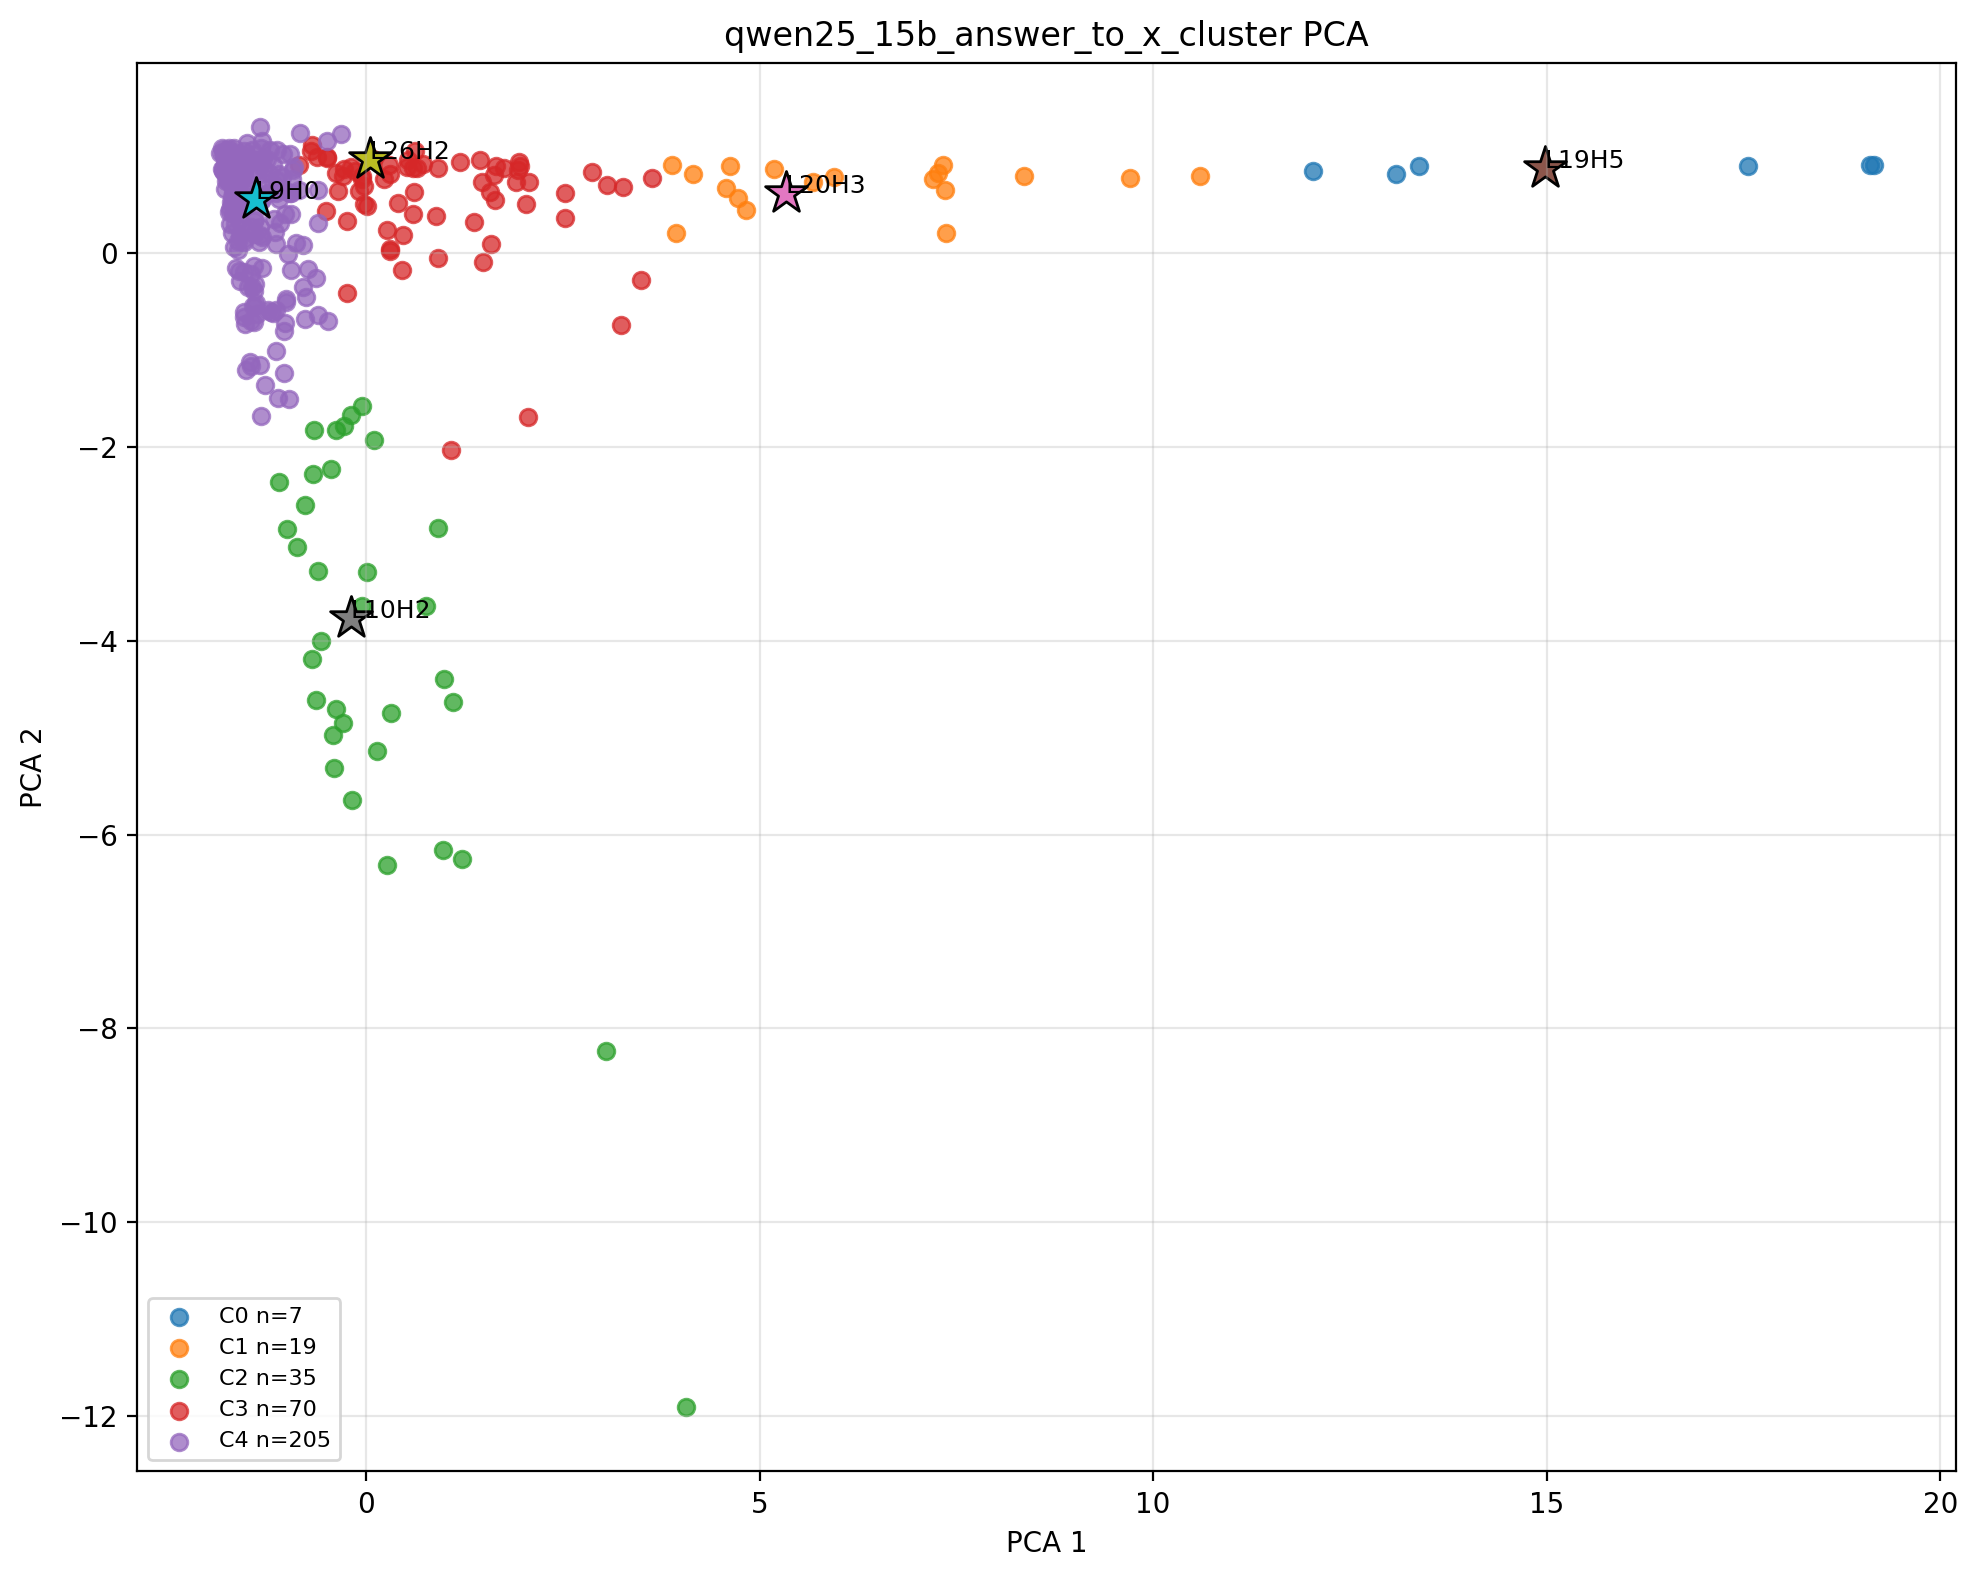

In [11]:
show_image(cluster_result['output_paths']['pca'], width=850)
show_image(cluster_result['output_paths']['overview_no_merge'])
show_image(cluster_result['output_paths']['overview_merge'])

### 4.3 Base vs Instruct Contrastive Selection

This Select-stage comparison uses the same prompt and the same answer-to-context/question attention region for two models:

- reference: `Qwen/Qwen2.5-1.5B`
- target: `Qwen/Qwen2.5-1.5B-Instruct`

Instead of comparing rendered screenshots, IzzyViz extracts a feature vector for every `(layer, head)` from the raw attention tensor. It then compares the same layer/head location across models and ranks heads by:

`same-head feature distance × target-head salience`

Important parameters:

- `metrics`: feature vector dimensions. Here we reuse the clustering metrics.
- `scale='robust'`: robust feature scaling before distance computation.
- `distance_metric='euclidean'`: compares the target and reference vector for the same layer/head.
- `salience_method='norm'`: uses the target head feature-vector norm as absolute salience.
- `save_summary=SAVE_DATA_OUTPUTS`: controls JSON/data summary files.

Extracting base model head features from existing attentions...
Loading comparison model: Qwen/Qwen2.5-1.5B-Instruct
Top Base vs Instruct distinctive heads:
rank 01: L25 H7 combined=0.405 diff=0.60 salience=0.68
rank 02: L19 H5 combined=0.398 diff=1.00 salience=0.40
rank 03: L23 H6 combined=0.202 diff=0.53 salience=0.38
rank 04: L17 H4 combined=0.141 diff=0.27 salience=0.53
rank 05: L19 H3 combined=0.114 diff=0.13 salience=0.85
rank 06: L14 H4 combined=0.102 diff=0.17 salience=0.61
rank 07: L16 H0 combined=0.083 diff=0.25 salience=0.34
rank 08: L12 H1 combined=0.075 diff=0.16 salience=0.47
izzyviz_qwen25_outputs/04_base_vs_instruct_select/combined_distinctive_score_heatmap.png


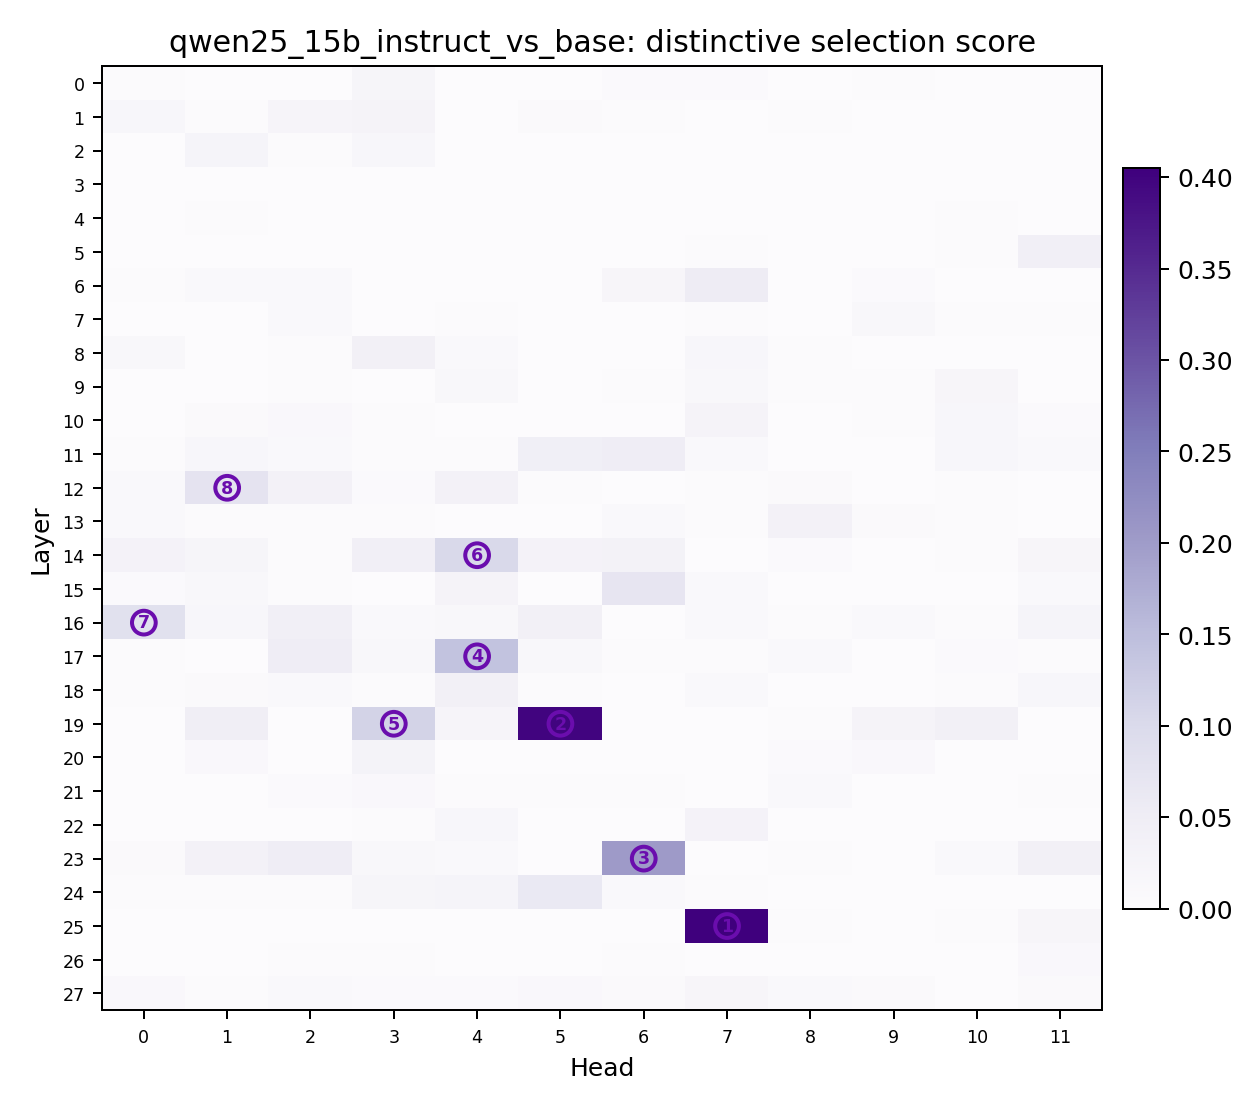

In [12]:
COMPARISON_MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
comparison_dir = OUTPUT_DIR / '04_base_vs_instruct_select'

feature_metrics = [
    'concentration',
    'entropy',
    'variance',
    'threshold_mass',
    'top_percent_mass',
    'low_range',
    'long_range',
]
feature_metric_params = {
    'threshold_mass': {'threshold': 0.05},
    'top_percent_mass': {'top_percent': 0.05},
    'low_range': {'max_distance': 5},
    'long_range': {'min_distance': 20},
}

print('Extracting base model head features from existing attentions...')
base_features = extract_attention_head_features(
    attentions,
    query_slice=(answer_start, answer_end),
    key_slice=(0, x_end),
    metrics=feature_metrics,
    metric_params=feature_metric_params,
    ignore_first_n=1,
)['features']

# The base model is no longer needed after selection/clustering. Free memory
# before loading the Instruct model for comparison.
del outputs, attentions, model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Loading comparison model:', COMPARISON_MODEL_NAME)
instruct_tokenizer = AutoTokenizer.from_pretrained(COMPARISON_MODEL_NAME, trust_remote_code=True)
instruct_model = AutoModelForCausalLM.from_pretrained(
    COMPARISON_MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation='eager',
    trust_remote_code=True,
)
instruct_model.to(DEVICE)
instruct_model.eval()

instruct_inputs = instruct_tokenizer(prompt, return_tensors='pt', add_special_tokens=False).to(DEVICE)
instruct_tokens = instruct_tokenizer.convert_ids_to_tokens(instruct_inputs['input_ids'][0])
instruct_x_end = len(instruct_tokenizer(x_text, add_special_tokens=False)['input_ids'])
instruct_answer_start = len(instruct_tokenizer(x_text + answer_prefix, add_special_tokens=False)['input_ids'])
instruct_answer_end = len(instruct_tokens)

with torch.no_grad():
    instruct_outputs = instruct_model(
        **instruct_inputs,
        output_attentions=True,
        return_dict=True,
        use_cache=False,
    )

instruct_features = extract_attention_head_features(
    instruct_outputs.attentions,
    query_slice=(instruct_answer_start, instruct_answer_end),
    key_slice=(0, instruct_x_end),
    metrics=feature_metrics,
    metric_params=feature_metric_params,
    ignore_first_n=1,
)['features']

base_vs_instruct_result = select_distinctive_attention_heads_by_features(
    target_features=instruct_features,
    reference_features=base_features,
    feature_names=feature_metrics,
    top_k=8,
    scale='robust',
    distance_metric='euclidean',
    salience_method='norm',
    output_dir=comparison_dir,
    run_name='qwen25_15b_instruct_vs_base',
    plot_heatmaps=True,
    save_summary=SAVE_DATA_OUTPUTS,
)

print('Top Base vs Instruct distinctive heads:')
for record in base_vs_instruct_result['top_records']:
    print(
        f"rank {record['rank']:02d}: L{record['layer']} H{record['head']} "
        f"combined={record['combined_score']:.3f} "
        f"diff={record['relative_score_normalized']:.2f} "
        f"salience={record['salience_score_normalized']:.2f}"
    )

show_image(base_vs_instruct_result['output_paths']['combined_distinctive_score_heatmap'], width=900)

# Keep the lightweight scalar results, then free the comparison model.
del instruct_outputs, instruct_model, instruct_tokenizer, instruct_inputs
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## 5. Inspect

Inspection focuses on one selected attention head and produces the detailed IzzyViz heatmap.

`visualize_attention_matrix` important parameters:

- `matrix`: a 2D attention-like matrix. Here shape is `[answer_tokens, context_question_tokens]`.
- `x_labels`: labels for columns, here context + question tokens.
- `y_labels`: labels for rows, here answer tokens.
- `top_n`: number of strongest cells to highlight and enlarge.
- `enlarged_size`: how much to enlarge rows/columns that contain top cells.
- `gamma`: power normalization for color contrast; larger values make low/mid values lighter.
- `cmap`: color map. IzzyViz defaults to `Purples`.
- `merge_virtual_tokens=True`: compress contiguous unimportant token runs into virtual tokens.
- `virtual_token_min_run`: minimum unimportant run length before compression.
- `length_threshold`: if token count is large, labels become sparse.
- `if_top_cells=True`: in sparse-label mode, still show labels for top-cell rows/columns.
- `show_scores_in_enlarged_cells`: whether to write numeric scores in enlarged cells. This is off here to keep long-context figures clean.
- `save_path`: output path. Use `.png` for notebooks and `.pdf` for publication export.

Edit `USER_LAYER` and `USER_HEAD` to inspect any head. The default is the first cluster representative.

Showing L 19 H 5
izzyviz_qwen25_outputs/04_inspect_L19_H5_virtual_tokens.png


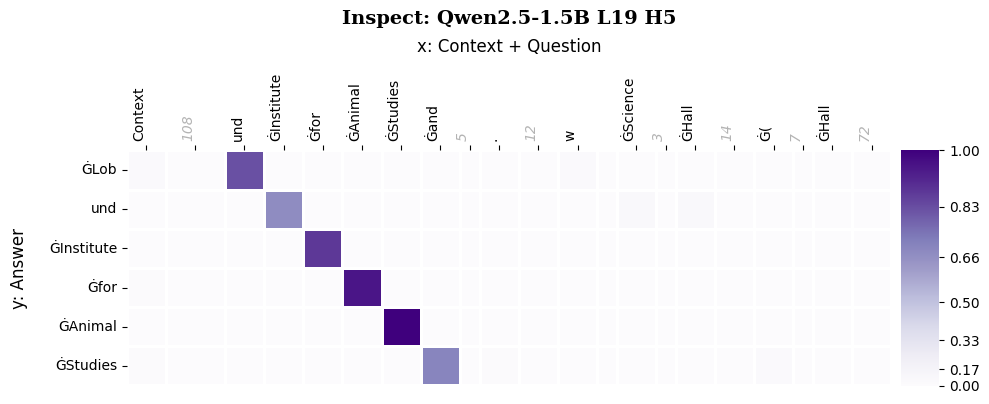

In [13]:
if representative_records:
    USER_LAYER = representative_records[0]['layer']
    USER_HEAD = representative_records[0]['head']
else:
    USER_LAYER = selection_result['top_records'][0]['layer']
    USER_HEAD = selection_result['top_records'][0]['head']

print('Showing L', USER_LAYER, 'H', USER_HEAD)
user_matrix = attention_region[USER_LAYER, USER_HEAD]

inspect_path = OUTPUT_DIR / f'04_inspect_L{USER_LAYER}_H{USER_HEAD}_virtual_tokens.png'
ax, _ = visualize_attention_matrix(
    user_matrix,
    x_labels=x_labels,
    y_labels=y_labels,
    title=f'Inspect: Qwen2.5-1.5B L{USER_LAYER} H{USER_HEAD}',
    xlabel='x: Context + Question',
    ylabel='y: Answer',
    top_n=20,
    enlarged_size=2.0,
    gamma=1.5,
    cmap='Purples',
    merge_virtual_tokens=True,
    virtual_token_min_run=2,
    length_threshold=64,
    if_interval=False,
    if_top_cells=True,
    show_scores_in_enlarged_cells=False,
    lean_more=True,
    save_path=inspect_path,
    close_after_save=True,
)
show_image(inspect_path)

## 6. Explore

Explore means applying the same workflow under different experimental settings to answer research questions. This tutorial does not add extra Explore code yet; possible use cases include:

- **Prompt sensitivity:** compare attention when the question wording changes but the context stays fixed.
- **Evidence localization:** check whether answer tokens attend to the exact evidence sentence or to irrelevant context.
- **Context length analysis:** increase context length and inspect whether virtual-token views still preserve salient evidence.
- **Model comparison:** run the same prompt on base, instruct, math, or coder variants of Qwen and compare selected heads.
- **Faithfulness analysis:** compare correct vs incorrect answers and inspect whether answer tokens attend to evidence or distractors.
- **Layer/head taxonomy:** use metric selection and clustering across many prompts to identify recurring attention behaviors.

The sections below are visualization variants, not the Explore workflow itself.

## 7. Visualization Variants

The core Explore workflow is about applying attention analysis under different experimental settings. The following cells are **visualization variants** that can be used inside those applications.

### 7.1 Comparison Heatmap

The comparison heatmap preserves information from two attention matrices in one figure:

- cell color: attention values from `attn1`
- circle color: attention values from `attn2`
- circle size: absolute difference between `attn1` and `attn2`

Important parameters:

- `attn1`, `attn2`: two attention matrices with the same shape.
- `tokens`: axis labels. This built-in variant is designed for square self-attention matrices.
- `circle_scale`: increases/decreases circle sizes.
- `gamma`: power normalization for color contrast.
- `max_circle_ratio`: caps circle radius so circles do not fill cells completely.

This example follows the earlier Colab tutorial style and compares two BERT heads.

Attention comparison heatmap with circles saved to izzyviz_qwen25_outputs/05_comparison_heatmap_bert_layer8_vs_layer9.png
izzyviz_qwen25_outputs/05_comparison_heatmap_bert_layer8_vs_layer9.png


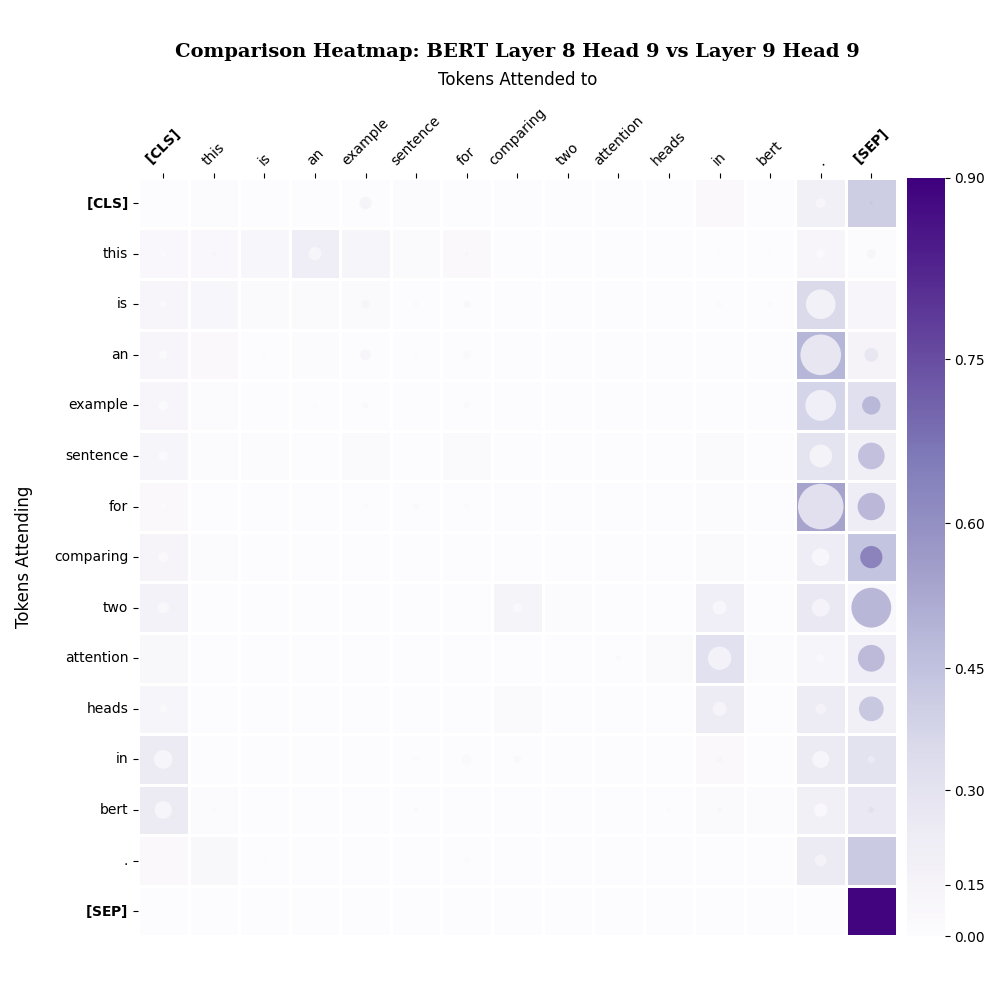

In [14]:
from transformers import AutoTokenizer, AutoModel

bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased', output_attentions=True)
bert_model.eval()

comparison_text = 'This is an example sentence for comparing two attention heads in BERT.'
bert_inputs = bert_tokenizer(comparison_text, return_tensors='pt')

with torch.no_grad():
    bert_outputs = bert_model(**bert_inputs, output_attentions=True, return_dict=True)

if bert_outputs.attentions is None or len(bert_outputs.attentions) < 9:
    raise ValueError(f'Expected at least 9 attention layers, got {None if bert_outputs.attentions is None else len(bert_outputs.attentions)}')

# Compare head 9 (zero-based index 8) from layers 8 and 9.
attn_layer8_head9 = bert_outputs.attentions[7][0, 8]
attn_layer9_head9 = bert_outputs.attentions[8][0, 8]
bert_tokens = bert_tokenizer.convert_ids_to_tokens(bert_inputs['input_ids'][0])

comparison_path = OUTPUT_DIR / '05_comparison_heatmap_bert_layer8_vs_layer9.png'
compare_two_attentions_with_circles(
    attn1=attn_layer8_head9,
    attn2=attn_layer9_head9,
    tokens=bert_tokens,
    title='Comparison Heatmap: BERT Layer 8 Head 9 vs Layer 9 Head 9',
    xlabel='Tokens Attended to',
    ylabel='Tokens Attending',
    save_path=comparison_path,
    circle_scale=1.0,
    gamma=1.5,
    cmap='Purples',
    max_circle_ratio=0.45,
)
show_image(comparison_path, width=900)

### 7.2 Stability Heatmap

The stability heatmap visualizes how consistent an attention pattern is across repeated runs or experimental conditions.

- cell color: mean attention value across runs
- circle size: variability / confidence interval
- circle gradient: lower-to-upper range of attention values

Important parameters:

- `matrices`: shape `[runs, rows, cols]`.
- `use_std_error`: if `True`, circle size uses standard error; if `False`, raw standard deviation.
- `circle_scale`: adjusts circle radius.
- `radial_resolution`: controls gradient smoothness.
- `color_contrast_scale`: increases/decreases center-edge contrast.

This example downloads a precomputed `.npy` file from Google Drive, matching the earlier Colab tutorial style.

Check Stability heatmap saved to izzyviz_qwen25_outputs/06_stability_heatmap_gradient_runs.png
izzyviz_qwen25_outputs/06_stability_heatmap_gradient_runs.png


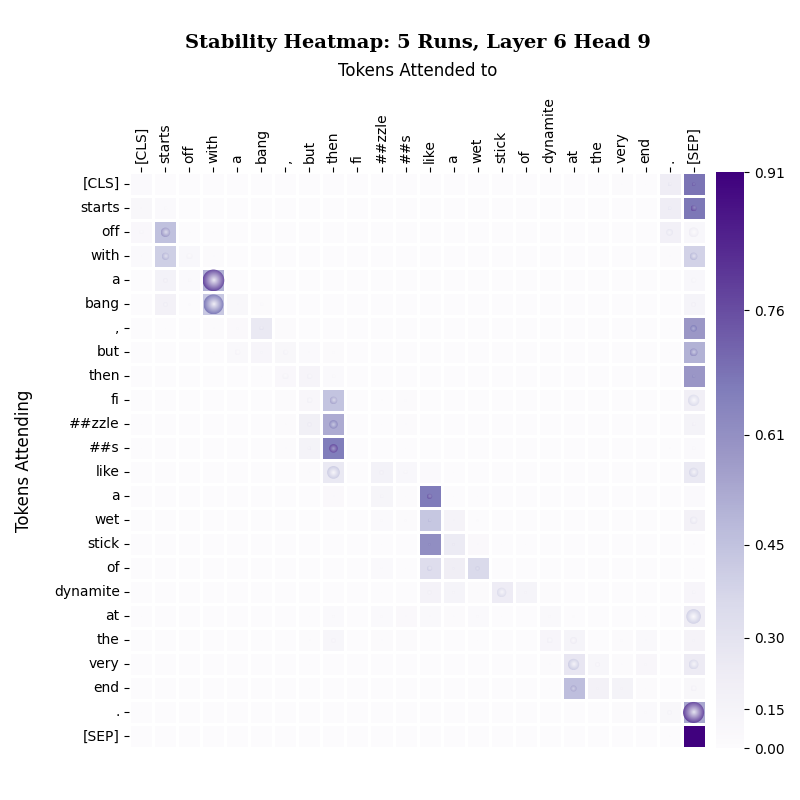

In [15]:
import gdown

stability_file_id = '1WExz02uZSCDo9GB3TKF-E9oqI-bfzOw3'
stability_file = OUTPUT_DIR / 'attention_matrices_5_runs_test_sample.npy'
if not stability_file.exists():
    gdown.download(id=stability_file_id, output=str(stability_file), quiet=False)

# Saved shape: [runs, layers, heads, query_tokens, key_tokens].
stability_array = np.load(stability_file, allow_pickle=True)

layer_idx = 6
head_idx = 9
stability_head = stability_array[:, layer_idx, head_idx, :, :]
stability_submatrix = stability_head[:, :24, :24]

stability_labels = [
    '[CLS]', 'starts', 'off', 'with', 'a', 'bang', ',', 'but', 'then', 'fi',
    '##zzle', '##s', 'like', 'a', 'wet', 'stick', 'of', 'dynamite', 'at',
    'the', 'very', 'end', '.', '[SEP]'
]

stability_path = OUTPUT_DIR / '06_stability_heatmap_gradient_runs.png'
check_stability_heatmap_with_gradient_color(
    stability_submatrix,
    x_labels=stability_labels,
    y_labels=stability_labels,
    title='Stability Heatmap: 5 Runs, Layer 6 Head 9',
    xlabel='Tokens Attended to',
    ylabel='Tokens Attending',
    save_path=stability_path,
    use_std_error=True,
    circle_scale=1.0,
    cmap='Purples',
    radial_resolution=100,
    color_contrast_scale=2.0,
    max_circle_ratio=0.45,
)
show_image(stability_path, width=900)

### 7.3 Evolution Heatmap

The evolution heatmap shows how attention changes over training checkpoints or epochs.

- cell color: average attention value over time
- sparkline: cell-level trajectory across epochs/checkpoints

Important parameters:

- `attentions_over_time`: shape `[time, layers, heads, rows, cols]`.
- `layer`, `head`: the head to visualize.
- `normalize_sparklines`: if `True`, each cell sparkline is normalized independently; if `False`, all sparklines share a global value range.
- `sparkline_color_dark` and `sparkline_color_light`: line colors used over lower- and higher-intensity cells.

This example downloads precomputed checkpoint attentions from Google Drive.

Figure saved to izzyviz_qwen25_outputs/07_evolution_heatmap_sparklines_epochs.png
izzyviz_qwen25_outputs/07_evolution_heatmap_sparklines_epochs.png


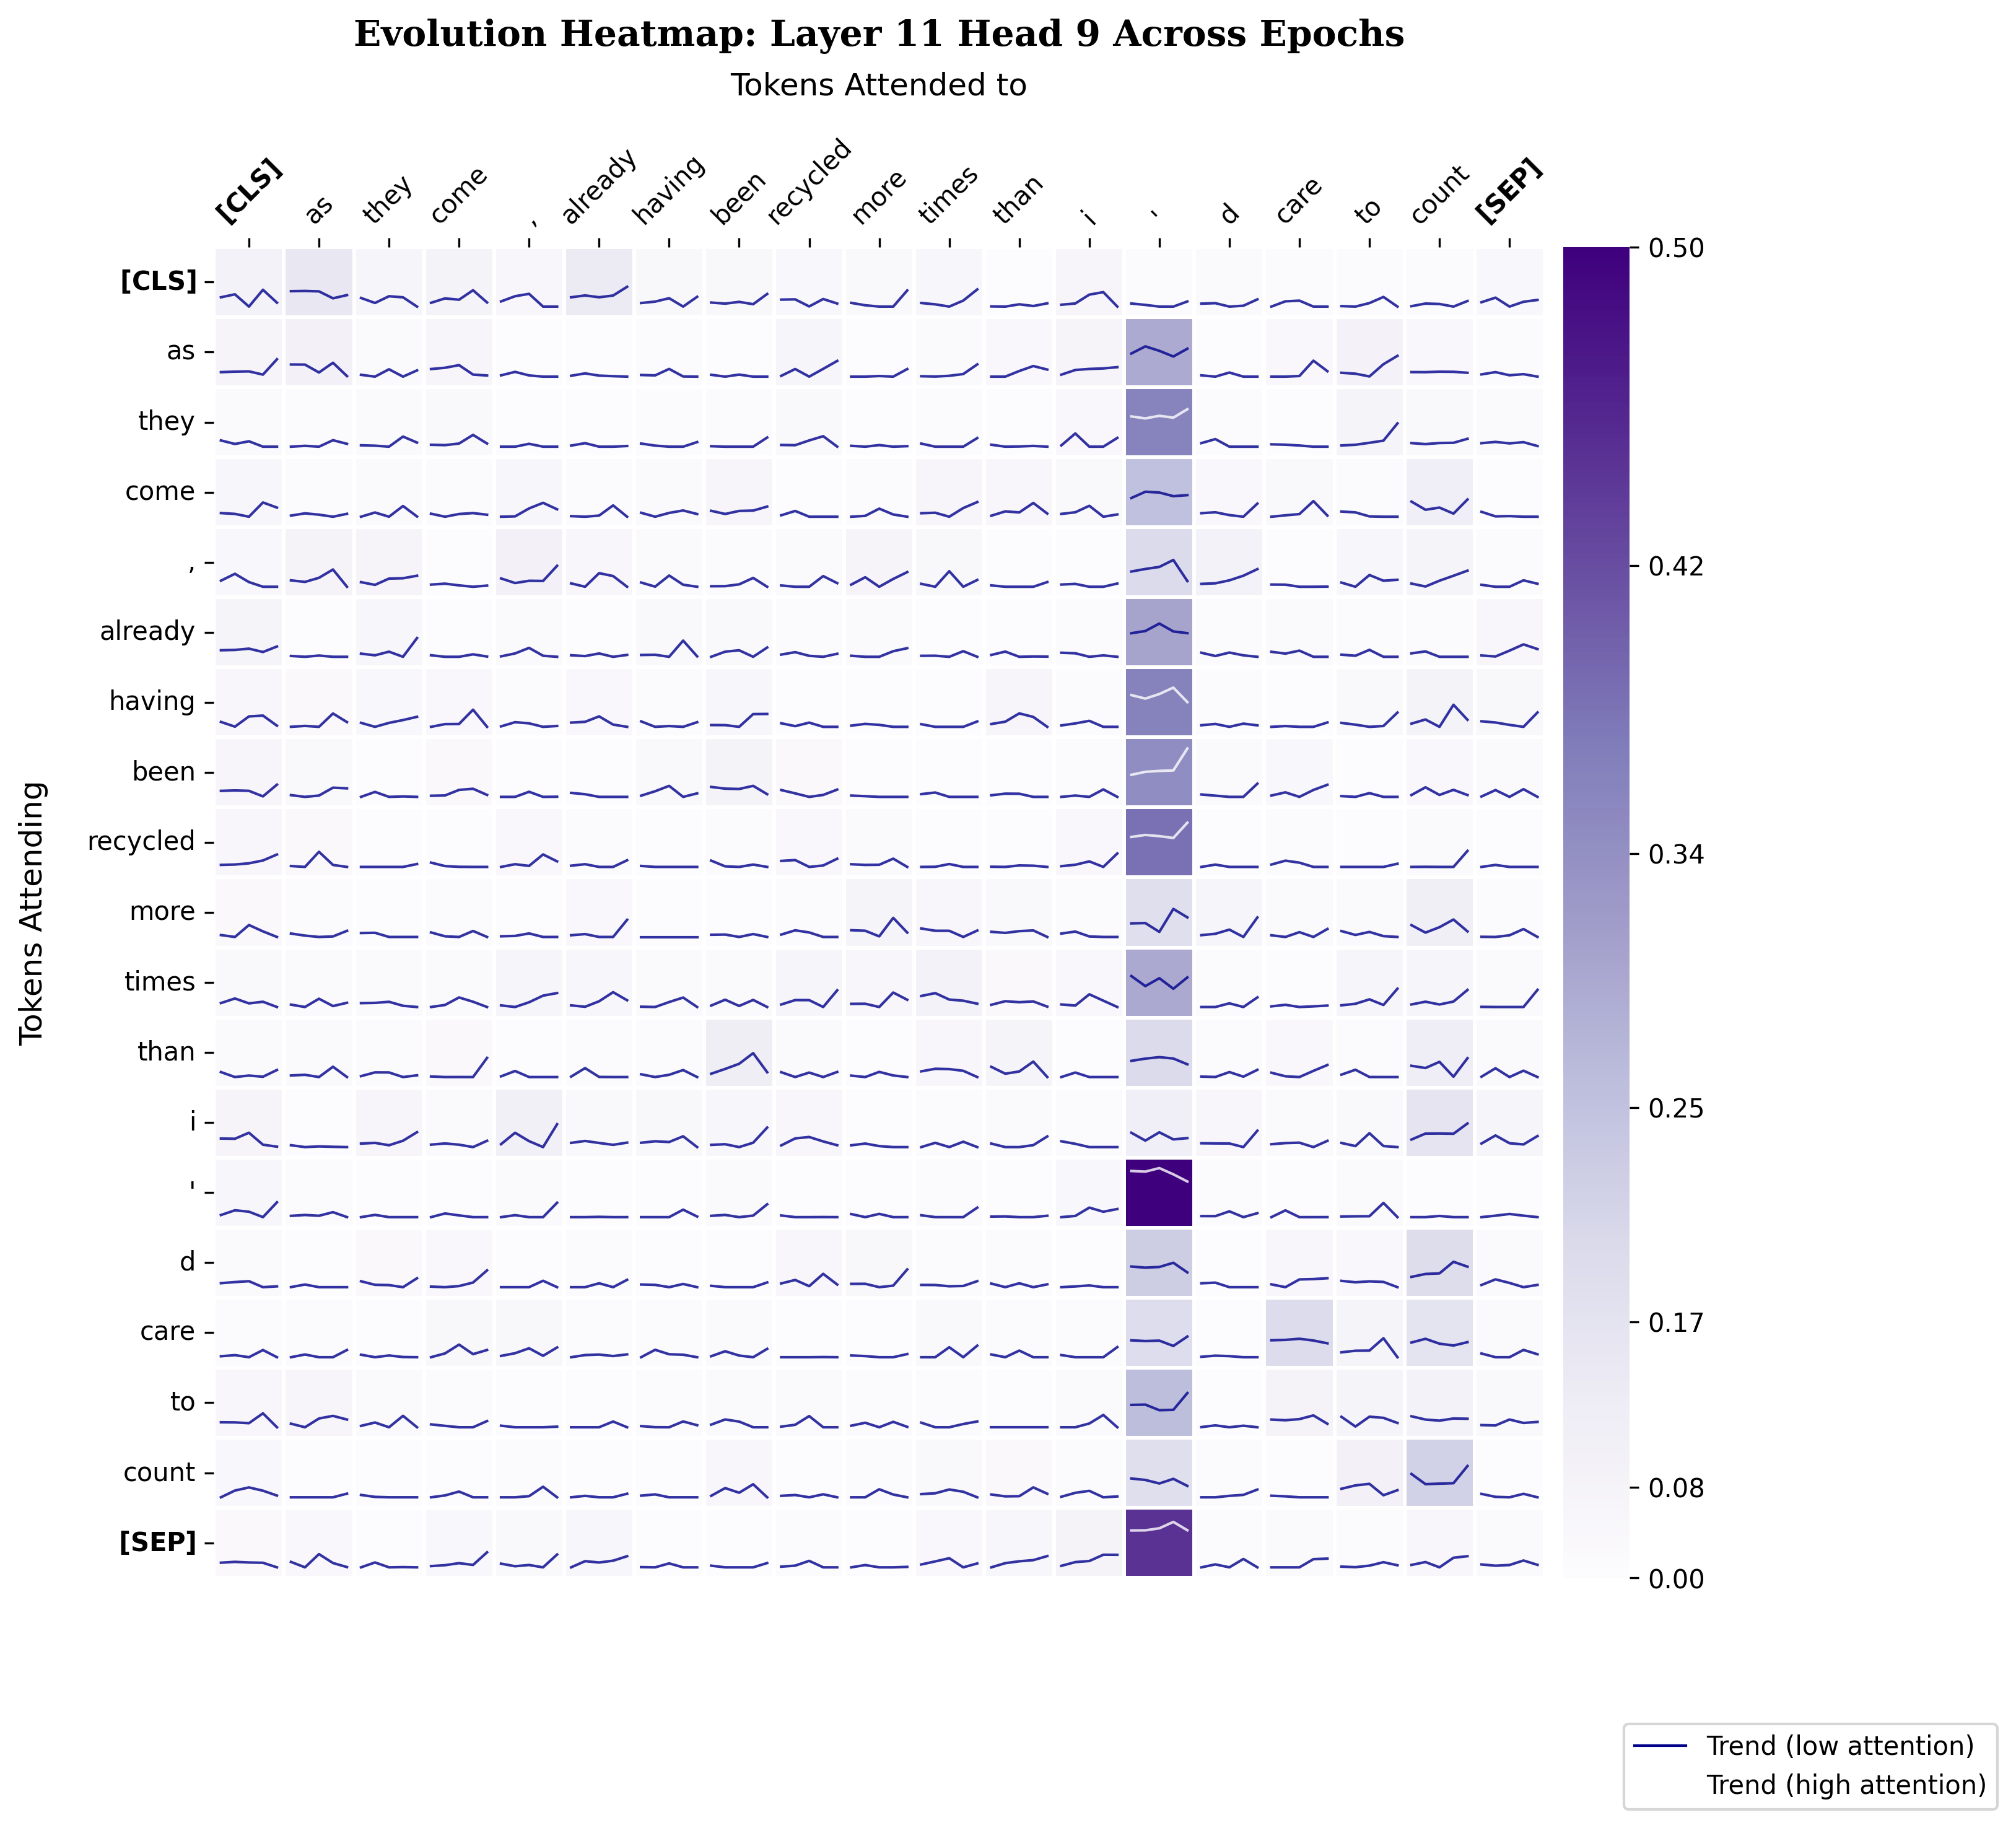

In [16]:
evolution_file_id = '13igcG4dPiIqR7YNQitdaCz8UtbYv-x14'
evolution_file = OUTPUT_DIR / 'attention_matrices_epochs.npy'
if not evolution_file.exists():
    gdown.download(id=evolution_file_id, output=str(evolution_file), quiet=False)

# Saved shape: [epochs, layers, heads, query_tokens, key_tokens].
evolution_array = np.load(evolution_file)
evolution_selected = evolution_array[:, :, :, :19, :19]

evolution_tokens = [
    '[CLS]', 'as', 'they', 'come', ',', 'already', 'having', 'been',
    'recycled', 'more', 'times', 'than', 'i', "'", 'd', 'care', 'to',
    'count', '[SEP]'
]

evolution_path = OUTPUT_DIR / '07_evolution_heatmap_sparklines_epochs.png'
ax = visualize_attention_evolution_sparklines(
    evolution_selected,
    tokens=evolution_tokens,
    layer=11,
    head=9,
    title='Evolution Heatmap: Layer 11 Head 9 Across Epochs',
    xlabel='Tokens Attended to',
    ylabel='Tokens Attending',
    save_path=evolution_path,
    normalize_sparklines=False,
)
plt.close(ax.figure)
show_image(evolution_path, width=900)

## 8. Summary and Cleanup

In [17]:
metadata = {
    'model_name': MODEL_NAME,
    'sequence_length': len(tokens),
    'x_span_context_question': [0, x_end],
    'y_span_answer': [answer_start, answer_end],
    'num_layers': num_layers,
    'num_heads': num_heads,
    'selection_top_records': selection_result['top_records'],
    'cluster_representatives': representative_records,
}
(OUTPUT_DIR / 'run_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

artifacts = sorted(str(p.relative_to(OUTPUT_DIR)) for p in OUTPUT_DIR.rglob('*') if p.is_file())
print(f'{len(artifacts)} files under {OUTPUT_DIR}:')
for item in artifacts[:120]:
    print('-', item)

# Optional cleanup:
# del outputs, attentions, model
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
# gc.collect()

43 files under izzyviz_qwen25_outputs:
- 01_pure_overview_answer_to_context_question.png
- 01_pure_overview_answer_to_context_question_merge_tokens.png
- 02_select_long_range/importance_heatmap.png
- 02_select_long_range/metric_selection_summary.json
- 02_select_long_range/overview_merge_tokens.png
- 02_select_long_range/overview_no_merge.png
- 02_select_long_range/rank_01_L0_H10_attention.png
- 02_select_long_range/rank_01_L8_H3_attention.png
- 02_select_long_range/rank_02_L14_H3_attention.png
- 02_select_long_range/rank_03_L19_H3_attention.png
- 02_select_long_range/rank_03_L8_H3_attention.png
- 02b_distinctive_difference_salience/absolute_salience_heatmap.png
- 02b_distinctive_difference_salience/combined_distinctive_score_heatmap.png
- 02b_distinctive_difference_salience/distinctive_head_selection_summary.json
- 02b_distinctive_difference_salience/relative_difference_heatmap.png
- 03_cluster_representative_heads/cluster_0_L19_H5.pdf
- 03_cluster_representative_heads/cluster_0_L23_H